# Режим 2 : Synthetic Poison Injection


## Протокол исследования: Режим 2

| Параметр | Значение |
|---|---|
| **Генератор** | CTGAN, обученный в Режиме 1 (загружается с диска) |
| **Метод инъекции** | Замена доли $\rho$ чистых обучающих примеров синтетическими отравленными |
| **Размер обучающей выборки** | Фиксирован (как в Режиме 1) |
| **Атаки** | LF-R2 (синтетика с перевёрнутыми метками), FP-R2 (синтетика с возмущением признаков), BD-R2 (синтетика с триггером) |
| **Доля отравления $\rho$** | $\{0.5\%,\ 1\%,\ 2\%,\ 5\%,\ 10\%\}$ |
| **Доля смешивания $\alpha$** | $\{0.0,\ 0.25,\ 0.5,\ 0.75,\ 1.0\}$ - как в Режиме 1 |
| **Случайные инициализации** | $\{42,\ 123,\ 456,\ 789,\ 1024\}$ |
| **Модели** | LogReg, XGBoost (ядро), MLP (только для backdoor) |
| **Основная метрика** | ROC-AUC на чистой реальной отложенной выборке $D_{\text{test}}$ |


## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
PROJECT = '/content/drive/MyDrive/diploma'
os.chdir(PROJECT)
os.makedirs('results/regime2', exist_ok=True)
os.makedirs('figures/regime2', exist_ok=True)
print(f'Working directory: {os.getcwd()}')

Working directory: /content/drive/MyDrive/diploma


In [3]:
!pip install sdv xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 139.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 12.1 MB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

SEED = 42
SEEDS = [42, 123, 456, 789, 1024]
POISON_RATES = [0.005, 0.01, 0.02, 0.05, 0.10]
ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0]
LAMBDAS = [0.5, 1.0, 2.0]
CORE_MODELS = ['LogReg', 'XGBoost']

DATASETS = {
    'adult': 'income',
    'bank':  'y',
}

np.random.seed(SEED)
print('Config loaded.')

Config loaded.


## 1. Загрузка сохранённого состояния из Режима 1



In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sdv.single_table import CTGANSynthesizer

def get_core_models():
    return {
        'LogReg': LogisticRegression(max_iter=1000, random_state=SEED),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            eval_metric='logloss', random_state=SEED, verbosity=0),
    }

DS_STATE = {}

for name, target_col in DATASETS.items():
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)

    scaler = StandardScaler()
    scaler.mean_  = np.array(meta['scaler_mean'])
    scaler.scale_ = np.array(meta['scaler_scale'])
    scaler.var_   = scaler.scale_ ** 2
    scaler.n_features_in_ = len(meta['num_idx'])

    DS_STATE[name] = {
        'meta': meta,
        'scaler': scaler,
        'target_col': target_col,
    }
    print(f'[{name}] meta loaded - {meta["train_size"]} train, {meta["test_size"]} test')

print('\nLoading Regime 1 results...')
lf_r1 = pd.read_csv('results/label_flip_all.csv')
fp_r1 = pd.read_csv('results/feature_perturb_all.csv')
print(f'  LF R1: {len(lf_r1)} rows, FP R1: {len(fp_r1)} rows')

[adult] meta loaded - 19536 train, 6513 test
[bank] meta loaded - 24712 train, 8238 test

Loading Regime 1 results...
  LF R1: 600 rows, FP R1: 1600 rows


In [6]:
print('Loading')
for name in DATASETS:
    path = f'data/synthetic/{name}_ctgan.pkl'
    if os.path.exists(path):
        DS_STATE[name]['ctgan'] = CTGANSynthesizer.load(path)
        print(f'[{name}] CTGAN loaded from {path}')
    else:
        print(f'[{name}]No saved CTGAN found at {path}')
        print(f'Please run the core benchmark notebook first.')

for name, target_col in DATASETS.items():
    syn_path = f'data/synthetic/{name}_syn.csv'
    if os.path.exists(syn_path):
        DS_STATE[name]['syn_df'] = pd.read_csv(syn_path)
        print(f'  [{name}] syn_df loaded: {DS_STATE[name]["syn_df"].shape}')

Loading
  [adult] CTGAN loaded from data/synthetic/adult_ctgan.pkl
  [bank] CTGAN loaded from data/synthetic/bank_ctgan.pkl
  [adult] syn_df loaded: (19536, 15)
  [bank] syn_df loaded: (24712, 21)


## 2. Генерация синтетических отравленных точек

Ключевая функция Режима 2: сэмплирование свежих синтетических точек из CTGAN и применение выбранной трансформации отравления перед инъекцией.

Протокол инъекции:
1. Из чистой обучающей выборки $D(\alpha)$ удалить $\rho \cdot |D|$ случайно выбранных точек
2. Сэмплировать $\rho \cdot |D|$ новых точек из CTGAN
3. Применить трансформацию отравления к этим новым точкам
4. Объединить чистый остаток и отравленные синтетические точки → $\tilde{D}$

Это сохраняет $|\tilde{D}| = |D|$ фиксированным во всех экспериментах.

In [7]:
def encode_syn_df(syn_df, meta, scaler):
    from sklearn.preprocessing import LabelEncoder
    import pandas as pd

    df = syn_df.copy()
    target_col = meta['target_col']
    feature_names = meta['feature_names']
    train_raw = pd.read_csv(f"data/processed/{meta.get('name', '')}/train_raw.csv") \
        if False else None
    for c in meta['cat_cols']:
        if c in df.columns:
            if df[c].dtype == object:

                df[c] = pd.Categorical(df[c]).codes
            df[c] = df[c].astype(int)
    y = df[target_col].values.astype(int) if target_col in df.columns else None
    cols_to_use = [c for c in feature_names if c in df.columns]
    X = df[cols_to_use].values.astype(float)
    if len(meta['num_idx']) > 0:
        X[:, meta['num_idx']] = scaler.transform(X[:, meta['num_idx']])

    return X, y

def sample_synthetic_poison(name, n_poison, seed, ds_state):
    meta = ds_state['meta']
    scaler = ds_state['scaler']
    ctgan = ds_state['ctgan']
    syn_fresh = ctgan.sample(num_rows=n_poison + 50, output_file_path=None)
    syn_fresh = syn_fresh.sample(n=min(n_poison, len(syn_fresh)), random_state=seed)
    X_p, y_p = encode_syn_df(syn_fresh, meta, scaler)
    return X_p[:n_poison], y_p[:n_poison] if y_p is not None else np.zeros(n_poison, dtype=int)

def inject_synthetic_poison(X_clean, y_clean, X_poison, y_poison, rho, seed):
    rng = np.random.RandomState(seed)
    n = len(X_clean)
    n_poison = len(X_poison)
    remove_idx = rng.choice(n, size=n_poison, replace=False)
    keep_mask = np.ones(n, dtype=bool)
    keep_mask[remove_idx] = False

    X_combined = np.vstack([X_clean[keep_mask], X_poison])
    y_combined = np.concatenate([y_clean[keep_mask], y_poison])

    shuffle_idx = rng.permutation(len(X_combined))
    return X_combined[shuffle_idx], y_combined[shuffle_idx]

print('Regime 2 injection functions defined.')

Regime 2 injection functions defined.


## 3. Атака Режима 2: синтетика с перевёрнутыми метками (LF-R2)

Сэмплируем свежие синтетические точки из CTGAN, переворачиваем их метки, инжектируем в обучающую выборку.

In [ ]:
from joblib import Parallel, delayed

def lf_r2_one_seed(seed, alpha, rho, X_train, y_train,
                   X_poison, y_poison, X_test, y_test, name):
    if rho == 0.0 or X_poison is None:
        X_tr, y_tr = X_train.copy(), y_train.copy()
    else:
        y_p_flipped = 1 - y_poison
        X_tr, y_tr = inject_synthetic_poison(X_train, y_train, X_poison, y_p_flipped, rho, seed)

    rows = []
    for mname, model in get_core_models().items():
        model.fit(X_tr, y_tr)
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        rows.append({'dataset': name, 'alpha': alpha, 'regime': 'R2',
                     'attack': 'LF-R2', 'rho': rho, 'seed': seed,
                     'model': mname, 'test_auc': auc})
    return rows

def run_lf_regime2(name):
    ds_state = DS_STATE[name]
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')

    all_results = []
    for alpha in ALPHAS:
        tag = f'alpha_{alpha:.2f}'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')
        n_train = len(X_train)

        for rho in [0.0] + POISON_RATES:
            n_poison = int(rho * n_train)

            # Step 1: pre-sample poison sequentially (GPU)
            poison_by_seed = {}
            for seed in SEEDS:
                if n_poison > 0:
                    poison_by_seed[seed] = sample_synthetic_poison(name, n_poison, seed, ds_state)
                else:
                    poison_by_seed[seed] = (None, None)

            # Step 2: parallel training (CPU)
            seed_results = Parallel(n_jobs=-1, verbose=0)(
                delayed(lf_r2_one_seed)(
                    seed, alpha, rho, X_train, y_train,
                    poison_by_seed[seed][0], poison_by_seed[seed][1],
                    X_test, y_test, name)
                for seed in SEEDS)

            for rows in seed_results:
                all_results.extend(rows)
            print(f'  [{name}] LF-R2 alpha={alpha:.2f} rho={rho:.3f} done')

    return pd.DataFrame(all_results)

lf_r2_frames = []
for ds_name in DATASETS:
    print(f'{ds_name}: LF Regime 2')
    lf_r2_frames.append(run_lf_regime2(ds_name))

lf_r2 = pd.concat(lf_r2_frames, ignore_index=True)
lf_r2.to_csv('results/regime2/lf_r2_all.csv', index=False)
print(f'Saved: {len(lf_r2)} rows')

adult: LF Regime 2
  [adult] LF-R2 alpha=0.00 rho=0.000 done
  [adult] LF-R2 alpha=0.00 rho=0.005 done
  [adult] LF-R2 alpha=0.00 rho=0.010 done
  [adult] LF-R2 alpha=0.00 rho=0.020 done
  [adult] LF-R2 alpha=0.00 rho=0.050 done
  [adult] LF-R2 alpha=0.00 rho=0.100 done
  [adult] LF-R2 alpha=0.25 rho=0.000 done
  [adult] LF-R2 alpha=0.25 rho=0.005 done
  [adult] LF-R2 alpha=0.25 rho=0.010 done
  [adult] LF-R2 alpha=0.25 rho=0.020 done
  [adult] LF-R2 alpha=0.25 rho=0.050 done
  [adult] LF-R2 alpha=0.25 rho=0.100 done
  [adult] LF-R2 alpha=0.50 rho=0.000 done
  [adult] LF-R2 alpha=0.50 rho=0.005 done
  [adult] LF-R2 alpha=0.50 rho=0.010 done
  [adult] LF-R2 alpha=0.50 rho=0.020 done
  [adult] LF-R2 alpha=0.50 rho=0.050 done
  [adult] LF-R2 alpha=0.50 rho=0.100 done
  [adult] LF-R2 alpha=0.75 rho=0.000 done
  [adult] LF-R2 alpha=0.75 rho=0.005 done
  [adult] LF-R2 alpha=0.75 rho=0.010 done
  [adult] LF-R2 alpha=0.75 rho=0.020 done
  [adult] LF-R2 alpha=0.75 rho=0.050 done
  [adult] LF-R2

## 4. Атака Режима 2: синтетика с изменением признаков (FP-R2)

Сэмплируем свежие синтетические точки из CTGAN, добавляем шум к признакам, инжектируем в обучающую выборку.

In [ ]:
def fp_r2_one_seed(seed, alpha, rho, lam, X_train, y_train,
                   X_poison_raw, y_poison_raw, meta, X_test, y_test, name):
    if rho == 0.0 or X_poison_raw is None:
        X_tr, y_tr = X_train.copy(), y_train.copy()
    else:
        X_p = X_poison_raw.copy()
        rng = np.random.RandomState(seed)
        if len(meta['num_idx']) > 0:
            noise = rng.normal(0, lam, size=(len(X_p), len(meta['num_idx'])))
            X_p[:, meta['num_idx']] += noise
        if len(meta['cat_idx']) > 0:
            for i in range(len(X_p)):
                col = rng.choice(meta['cat_idx'])
                vals = np.unique(X_train[:, col])
                X_p[i, col] = rng.choice(vals)
        X_tr, y_tr = inject_synthetic_poison(X_train, y_train, X_p, y_poison_raw, rho, seed)

    rows = []
    for mname, model in get_core_models().items():
        model.fit(X_tr, y_tr)
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        rows.append({'dataset': name, 'alpha': alpha, 'regime': 'R2',
                     'attack': 'FP-R2', 'rho': rho, 'lambda': lam, 'seed': seed,
                     'model': mname, 'test_auc': auc})
    return rows

def run_fp_regime2(name):
    ds_state = DS_STATE[name]
    meta = ds_state['meta']
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')

    all_results = []
    for alpha in ALPHAS:
        tag = f'alpha_{alpha:.2f}'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')
        n_train = len(X_train)

        for rho in [0.0] + POISON_RATES:
            n_poison = int(rho * n_train)

            # Pre-sample once per (alpha, rho, seed)
            poison_by_seed = {}
            for seed in SEEDS:
                if n_poison > 0:
                    poison_by_seed[seed] = sample_synthetic_poison(name, n_poison, seed, ds_state)
                else:
                    poison_by_seed[seed] = (None, None)

            for lam in (LAMBDAS if rho > 0 else [0.0]):
                seed_results = Parallel(n_jobs=-1, verbose=0)(
                    delayed(fp_r2_one_seed)(
                        seed, alpha, rho, lam, X_train, y_train,
                        poison_by_seed[seed][0], poison_by_seed[seed][1],
                        meta, X_test, y_test, name)
                    for seed in SEEDS)
                for rows in seed_results:
                    all_results.extend(rows)
                print(f'  [{name}] FP-R2 alpha={alpha:.2f} rho={rho:.3f} lambda={lam} done')

    return pd.DataFrame(all_results)

fp_r2_frames = []
for ds_name in DATASETS:
    print(f'{ds_name}: FP Regime 2')
    fp_r2_frames.append(run_fp_regime2(ds_name))

fp_r2 = pd.concat(fp_r2_frames, ignore_index=True)
fp_r2.to_csv('results/regime2/fp_r2_all.csv', index=False)
print(f'Saved: {len(fp_r2)} rows')

adult: FP Regime 2
  [adult] FP-R2 alpha=0.00 rho=0.000 lambda=0.0 done
  [adult] FP-R2 alpha=0.00 rho=0.005 lambda=0.5 done
  [adult] FP-R2 alpha=0.00 rho=0.005 lambda=1.0 done
  [adult] FP-R2 alpha=0.00 rho=0.005 lambda=2.0 done
  [adult] FP-R2 alpha=0.00 rho=0.010 lambda=0.5 done
  [adult] FP-R2 alpha=0.00 rho=0.010 lambda=1.0 done
  [adult] FP-R2 alpha=0.00 rho=0.010 lambda=2.0 done
  [adult] FP-R2 alpha=0.00 rho=0.020 lambda=0.5 done
  [adult] FP-R2 alpha=0.00 rho=0.020 lambda=1.0 done
  [adult] FP-R2 alpha=0.00 rho=0.020 lambda=2.0 done
  [adult] FP-R2 alpha=0.00 rho=0.050 lambda=0.5 done
  [adult] FP-R2 alpha=0.00 rho=0.050 lambda=1.0 done
  [adult] FP-R2 alpha=0.00 rho=0.050 lambda=2.0 done
  [adult] FP-R2 alpha=0.00 rho=0.100 lambda=0.5 done
  [adult] FP-R2 alpha=0.00 rho=0.100 lambda=1.0 done
  [adult] FP-R2 alpha=0.00 rho=0.100 lambda=2.0 done
  [adult] FP-R2 alpha=0.25 rho=0.000 lambda=0.0 done
  [adult] FP-R2 alpha=0.25 rho=0.005 lambda=0.5 done
  [adult] FP-R2 alpha=0.25 

## 5. Атака Режима 2: синтетика с триггером (BD-R2)

Сэмплируем синтетические точки, проставляем на них паттерн backdoor-триггера, устанавливаем целевую метку, инжектируем в обучающую выборку.

## Sanity-check триггерного паттерна

Согласно методологии BD-атак, триггер должен быть редким и не должен сам по себе коррелировать с целевой меткой в реальных данных. Иначе высокий ASR при $\rho=0$ означает, что мы измеряем не успех бэкдора, а статистическую связь признаков с target. Здесь проверяем эти свойства.

In [8]:
def trigger_sanity_check(name, target_label=1):
    """Проверка триггера: редкость и корреляция с y в чистых данных."""
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')
    X_train = np.load(f'data/processed/{name}/X_train.npy')
    y_train = np.load(f'data/processed/{name}/y_train.npy')
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)

    trigger_cols = meta['num_idx'][:2] if len(meta['num_idx']) >= 2 else meta['num_idx']
    trigger_vals = [3.0] * len(trigger_cols)
    tol = 0.1  # tolerance for "approximately matches trigger"

    print(f'[{name}] Trigger sanity check')
    print(f'Trigger cols: {[meta["feature_names"][c] for c in trigger_cols]}')
    print(f'Trigger vals (scaled): {trigger_vals}')

    # Frequency of the trigger pattern in clean train and test
    for split_name, X, y in [('train', X_train, y_train), ('test', X_test, y_test)]:
        matches = np.all(np.abs(X[:, trigger_cols] - trigger_vals) < tol, axis=1)
        freq = matches.mean()
        if matches.sum() > 0:
            y_freq = y[matches].mean()
        else:
            y_freq = float('nan')
        print(f'[{split_name}] natural trigger frequency = {freq:.4f}, '
              f'P(y=1 | trigger) = {y_freq:.4f} (vs base rate {y.mean():.4f})')

    # Target class distribution in test
    target_rate = (y_test == target_label).mean()
    print(f'Test base rate for target label y={target_label}: {target_rate:.4f}')
    print(f'-> baseline (chance) ASR is approximately {target_rate:.4f}')
    print()

for ds_name in ['adult', 'bank']:
    trigger_sanity_check(ds_name)

[adult] Trigger sanity check
  Trigger cols: ['age', 'fnlwgt']
  Trigger vals (scaled): [3.0, 3.0]
  [train] natural trigger frequency = 0.0000, P(y=1 | trigger) = nan (vs base rate 0.2408)
  [test] natural trigger frequency = 0.0000, P(y=1 | trigger) = nan (vs base rate 0.2407)
  Test base rate for target label y=1: 0.2407
  -> baseline (chance) ASR is approximately 0.2407

[bank] Trigger sanity check
  Trigger cols: ['age', 'duration']
  Trigger vals (scaled): [3.0, 3.0]
  [train] natural trigger frequency = 0.0000, P(y=1 | trigger) = nan (vs base rate 0.1127)
  [test] natural trigger frequency = 0.0000, P(y=1 | trigger) = nan (vs base rate 0.1126)
  Test base rate for target label y=1: 0.1126
  -> baseline (chance) ASR is approximately 0.1126



In [9]:
from sklearn.neural_network import MLPClassifier
from joblib import Parallel, delayed

def apply_trigger(X, trigger_cols, trigger_vals):
    X_t = X.copy()
    for col, val in zip(trigger_cols, trigger_vals):
        X_t[:, col] = val
    return X_t

def get_all_models():
    return {
        'LogReg': LogisticRegression(max_iter=1000, random_state=SEED),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            eval_metric='logloss', random_state=SEED, verbosity=0),
        'MLP': MLPClassifier(
            hidden_layer_sizes=(128, 64), max_iter=300,
            early_stopping=True, random_state=SEED, verbose=False),
    }


def compute_asr_metrics(model, X_test, y_test, X_test_trig, target_label):
    preds_trig = model.predict(X_test_trig)
    asr_full = (preds_trig == target_label).mean()
    nontarget_mask = (y_test != target_label)
    if nontarget_mask.sum() > 0:
        asr_nontarget = (preds_trig[nontarget_mask] == target_label).mean()
    else:
        asr_nontarget = float('nan')
    return asr_full, asr_nontarget


def bd_r2_one_seed(seed, alpha, rho, X_train, y_train, X_poison_raw,
                   trigger_cols, trigger_vals, target_label,
                   X_test, X_test_trig, y_test, name):
    if rho == 0.0 or X_poison_raw is None:
        X_tr, y_tr = X_train.copy(), y_train.copy()
    else:
        X_p_trig = apply_trigger(X_poison_raw, trigger_cols, trigger_vals)
        y_p_target = np.full(len(X_p_trig), target_label, dtype=int)
        X_tr, y_tr = inject_synthetic_poison(X_train, y_train, X_p_trig, y_p_target, rho, seed)

    rows = []
    for mname, model in get_all_models().items():
        model.fit(X_tr, y_tr)
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        asr_full, asr_nontarget = compute_asr_metrics(
            model, X_test, y_test, X_test_trig, target_label)
        rows.append({'dataset': name, 'alpha': alpha, 'regime': 'R2',
                     'attack': 'BD-R2', 'rho': rho, 'seed': seed,
                     'model': mname, 'test_auc': auc,
                     'asr': asr_full,
                     'asr_nontarget': asr_nontarget})
    return rows


def run_bd_regime2(name, target_label=1):
    ds_state = DS_STATE[name]
    meta = ds_state['meta']
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')

    trigger_cols = meta['num_idx'][:2] if len(meta['num_idx']) >= 2 else meta['num_idx']
    trigger_vals = [3.0] * len(trigger_cols)
    X_test_trig = apply_trigger(X_test, trigger_cols, trigger_vals)

    all_results = []
    for alpha in [0.0, 0.5, 1.0]:
        tag = f'alpha_{alpha:.2f}'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')
        n_train = len(X_train)

        for rho in [0.0] + POISON_RATES:
            n_poison = int(rho * n_train)
            poison_by_seed = {}
            for seed in SEEDS:
                if n_poison > 0:
                    X_p_raw, _ = sample_synthetic_poison(name, n_poison, seed, ds_state)
                    poison_by_seed[seed] = X_p_raw
                else:
                    poison_by_seed[seed] = None

            seed_results = Parallel(n_jobs=-1, verbose=0)(
                delayed(bd_r2_one_seed)(
                    seed, alpha, rho, X_train, y_train, poison_by_seed[seed],
                    trigger_cols, trigger_vals, target_label,
                    X_test, X_test_trig, y_test, name)
                for seed in SEEDS)
            for rows in seed_results:
                all_results.extend(rows)
            print(f'  [{name}] BD-R2 alpha={alpha:.2f} rho={rho:.3f} done')

    df = pd.DataFrame(all_results)

    # baseline-adjusted ASR
    df['asr_delta'] = float('nan')
    df['asr_nontarget_delta'] = float('nan')
    for (ds, a, m), sub in df.groupby(['dataset', 'alpha', 'model']):
        clean_full = sub.loc[sub['rho'] == 0.0, 'asr'].mean()
        clean_nt   = sub.loc[sub['rho'] == 0.0, 'asr_nontarget'].mean()
        mask = (df['dataset'] == ds) & (df['alpha'] == a) & (df['model'] == m)
        df.loc[mask, 'asr_delta']           = df.loc[mask, 'asr'] - clean_full
        df.loc[mask, 'asr_nontarget_delta'] = df.loc[mask, 'asr_nontarget'] - clean_nt

    return df

bd_r2_frames = []
for ds_name in DATASETS:
    print(f'{ds_name}: BD Regime 2')
    bd_r2_frames.append(run_bd_regime2(ds_name))

bd_r2 = pd.concat(bd_r2_frames, ignore_index=True)
bd_r2.to_csv('results/regime2/bd_r2_all.csv', index=False)
print(f'Saved: {len(bd_r2)} rows')

adult: BD Regime 2
  [adult] BD-R2 alpha=0.00 rho=0.000 done
  [adult] BD-R2 alpha=0.00 rho=0.005 done
  [adult] BD-R2 alpha=0.00 rho=0.010 done
  [adult] BD-R2 alpha=0.00 rho=0.020 done
  [adult] BD-R2 alpha=0.00 rho=0.050 done
  [adult] BD-R2 alpha=0.00 rho=0.100 done
  [adult] BD-R2 alpha=0.50 rho=0.000 done
  [adult] BD-R2 alpha=0.50 rho=0.005 done
  [adult] BD-R2 alpha=0.50 rho=0.010 done
  [adult] BD-R2 alpha=0.50 rho=0.020 done
  [adult] BD-R2 alpha=0.50 rho=0.050 done
  [adult] BD-R2 alpha=0.50 rho=0.100 done
  [adult] BD-R2 alpha=1.00 rho=0.000 done
  [adult] BD-R2 alpha=1.00 rho=0.005 done
  [adult] BD-R2 alpha=1.00 rho=0.010 done
  [adult] BD-R2 alpha=1.00 rho=0.020 done
  [adult] BD-R2 alpha=1.00 rho=0.050 done
  [adult] BD-R2 alpha=1.00 rho=0.100 done
bank: BD Regime 2
  [bank] BD-R2 alpha=0.00 rho=0.000 done
  [bank] BD-R2 alpha=0.00 rho=0.005 done
  [bank] BD-R2 alpha=0.00 rho=0.010 done
  [bank] BD-R2 alpha=0.00 rho=0.020 done
  [bank] BD-R2 alpha=0.00 rho=0.050 done
  

## 6. Сравнение: Режим 1 vs Режим 2 - Переворот меток

Красный = Режим 1 (искажение существующих точек).
Синий = Режим 2 (инъекция свежих синтетических отравленных точек).
Сплошная линия = реальные данные ($\alpha=1.0$), пунктир = синтетические ($\alpha=0.0$).

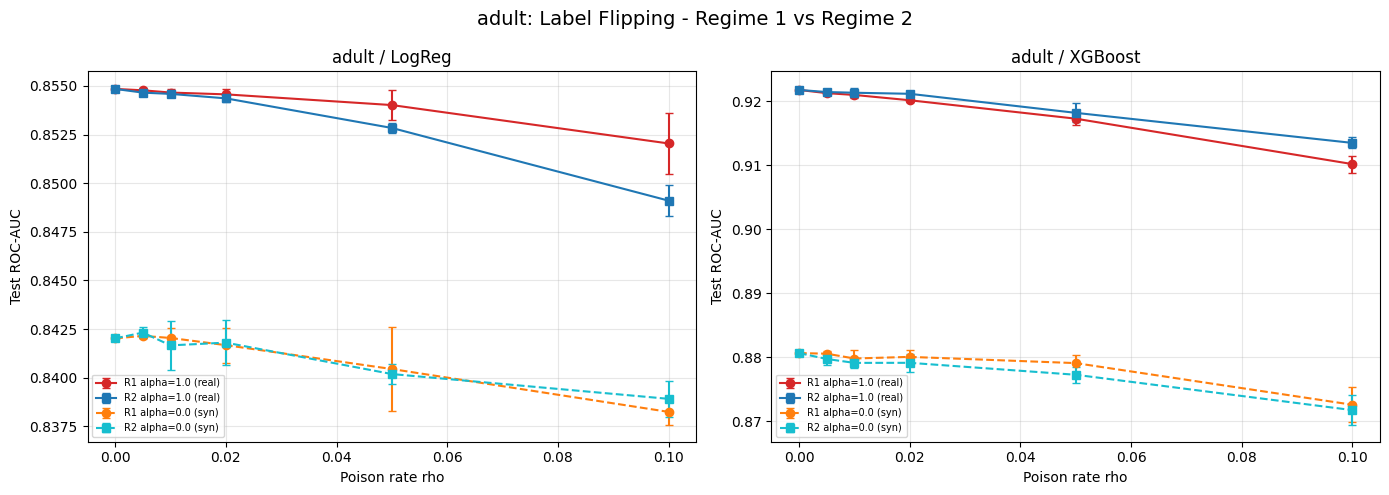

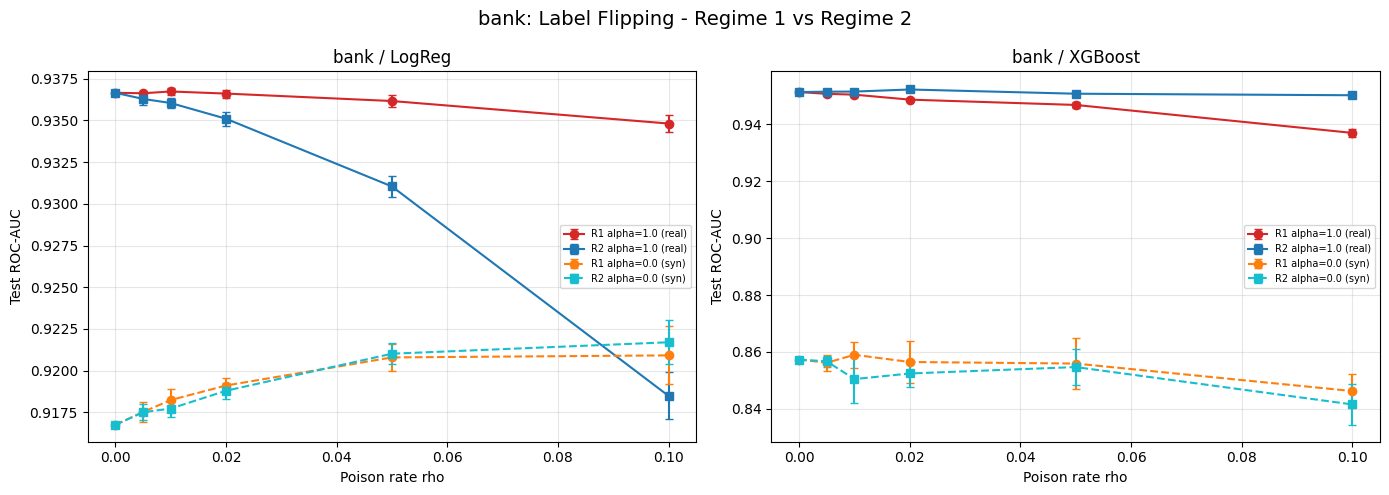

In [ ]:
def plot_r1_vs_r2(r1_df, r2_df, attack_r1, attack_r2, attack_label,
                  lambda_r1=None, models=CORE_MODELS):
    """Side-by-side degradation curves for R1 vs R2, per dataset and model."""

    datasets = sorted(r1_df['dataset'].unique())
    for name in datasets:
        r1 = r1_df[r1_df['dataset'] == name].copy()
        if lambda_r1 is not None:
            r1 = r1[(r1.get('lambda', lambda_r1) == lambda_r1) | (r1['rho'] == 0.0)].copy()
            r1.loc[r1['rho'] == 0.0, 'lambda'] = lambda_r1
        r2 = r2_df[r2_df['dataset'] == name].copy()

        fig, axes = plt.subplots(1, len(models), figsize=(7*len(models), 5))
        if len(models) == 1: axes = [axes]

        for j, mname in enumerate(models):
            for alpha, ls_real, ls_syn in [
                (1.0, '-', '--'),
                (0.0, '-', '--'),
            ]:
                # R1
                sub1 = r1[(r1['model']==mname) & (r1['alpha']==alpha)]
                agg1 = sub1.groupby('rho')['test_auc'].agg(['mean','std']).reset_index()
                label_r1 = f'R1 alpha={alpha:.1f} ({"real" if alpha==1.0 else "syn"})'
                color_r1 = 'tab:red' if alpha == 1.0 else 'tab:orange'
                axes[j].errorbar(agg1['rho'], agg1['mean'], yerr=agg1['std'],
                                 marker='o', capsize=3, color=color_r1,
                                 linestyle=ls_real if alpha==1.0 else ls_syn,
                                 label=label_r1)

                # R2
                sub2 = r2[(r2['model']==mname) & (r2['alpha']==alpha)]
                agg2 = sub2.groupby('rho')['test_auc'].agg(['mean','std']).reset_index()
                label_r2 = f'R2 alpha={alpha:.1f} ({"real" if alpha==1.0 else "syn"})'
                color_r2 = 'tab:blue' if alpha == 1.0 else 'tab:cyan'
                axes[j].errorbar(agg2['rho'], agg2['mean'], yerr=agg2['std'],
                                 marker='s', capsize=3, color=color_r2,
                                 linestyle=ls_real if alpha==1.0 else ls_syn,
                                 label=label_r2)

            axes[j].set_xlabel('Poison rate rho')
            axes[j].set_ylabel('Test ROC-AUC')
            axes[j].set_title(f'{name} / {mname}')
            axes[j].legend(fontsize=7)
            axes[j].grid(True, alpha=0.3)

        label_extra = f' (lambda={lambda_r1})' if lambda_r1 else ''
        plt.suptitle(f'{name}: {attack_label}{label_extra} - Regime 1 vs Regime 2', fontsize=14)
        plt.tight_layout()
        plt.savefig(f'figures/regime2/{name}_{attack_r2}_r1_vs_r2.png', dpi=150, bbox_inches='tight')
        plt.show()

plot_r1_vs_r2(lf_r1, lf_r2, 'LF', 'lf', 'Label Flipping')

## 7. Сравнение: Режим 1 vs Режим 2 - Feature Perturbation

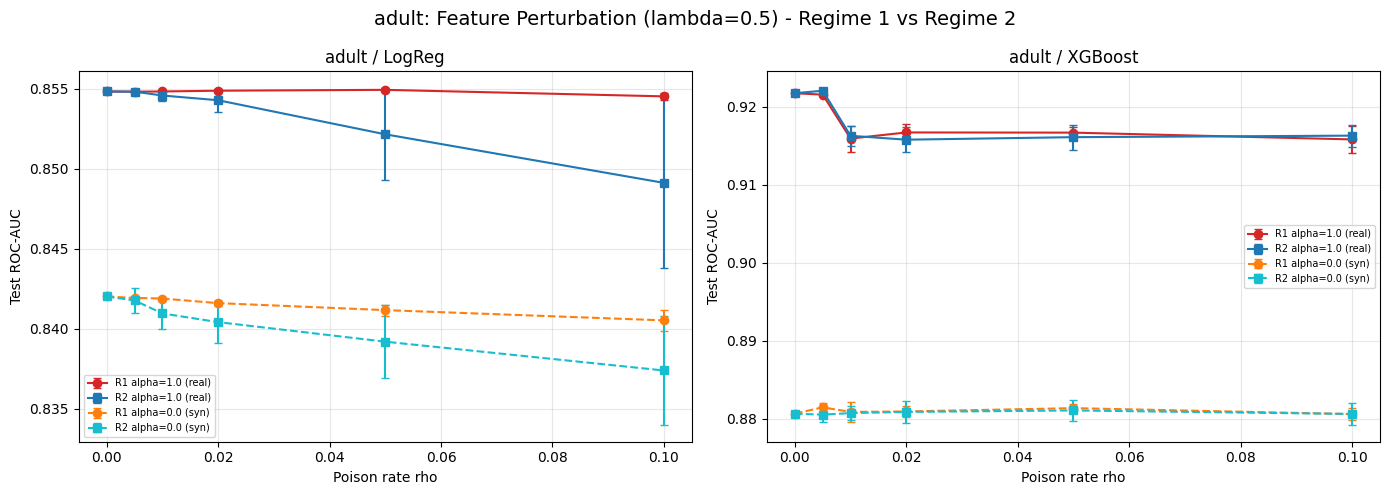

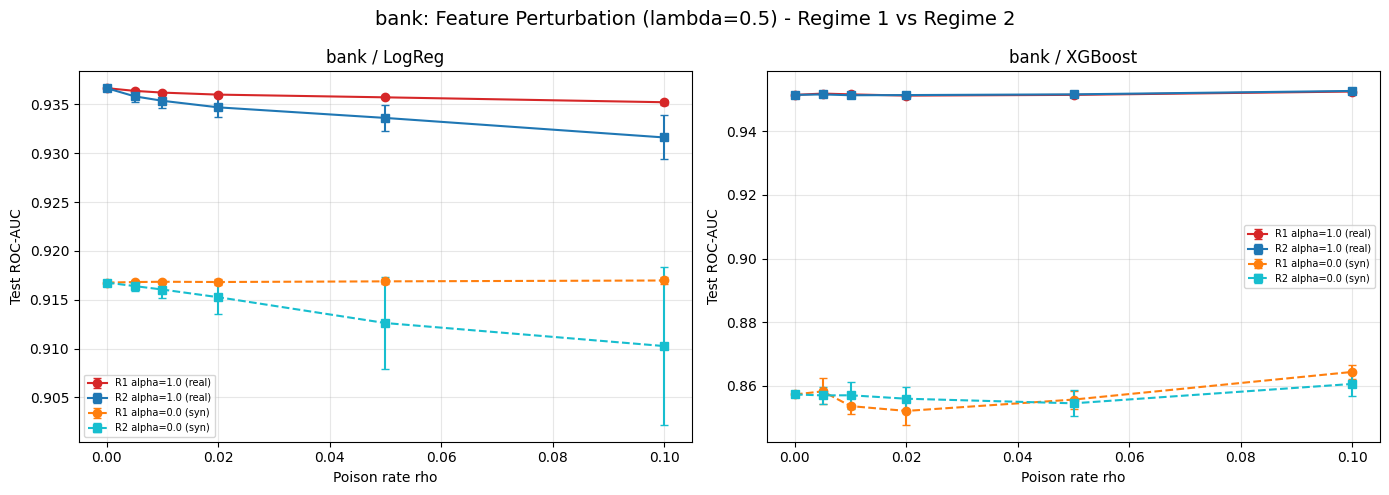

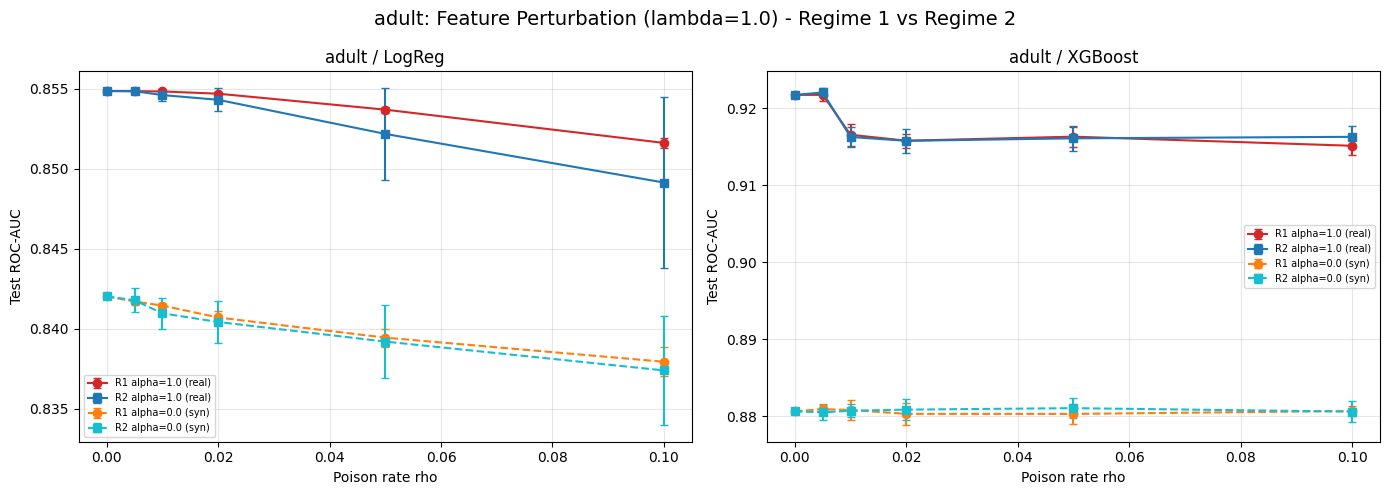

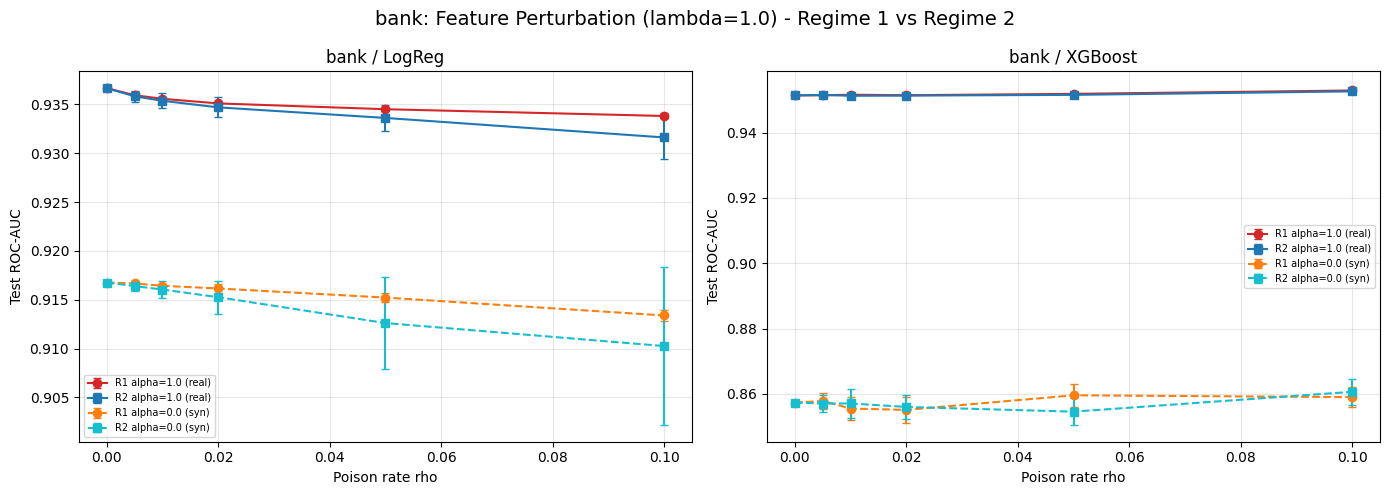

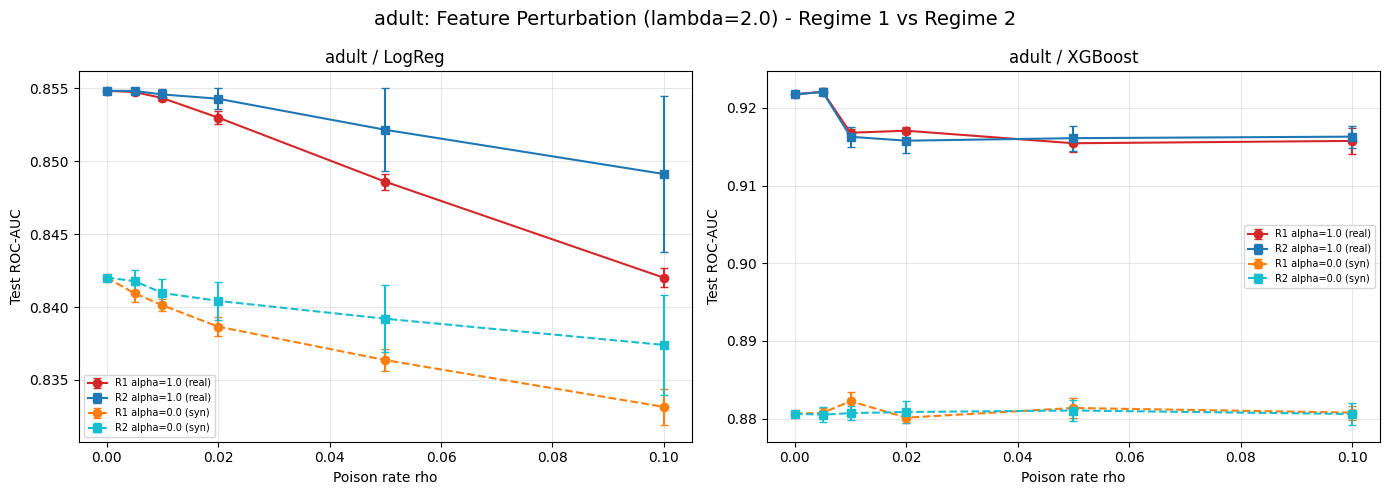

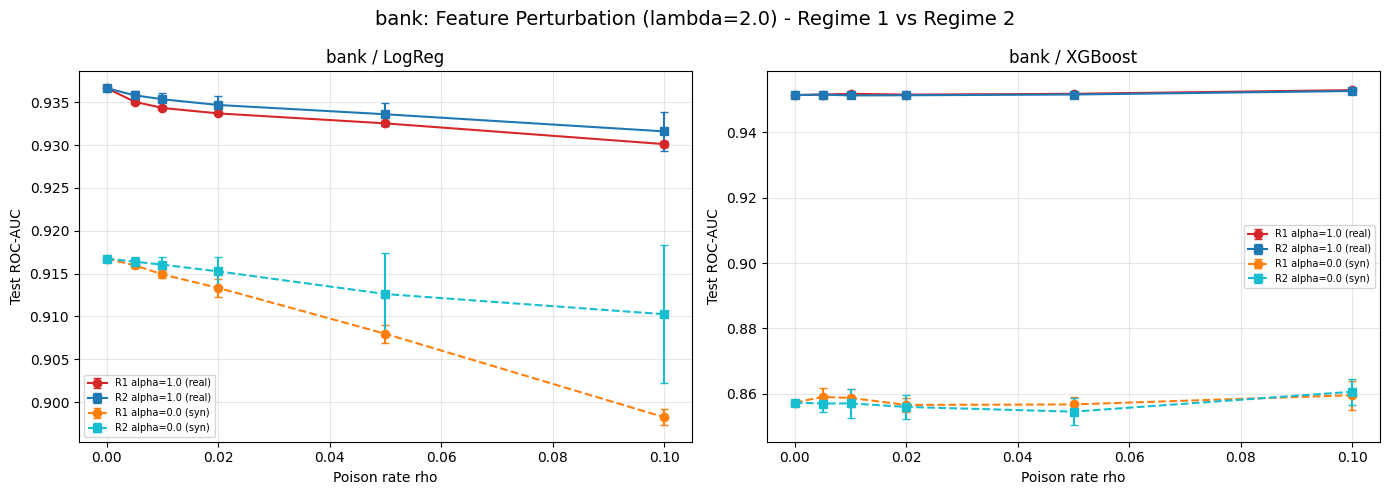

In [ ]:
for lam in LAMBDAS:
    plot_r1_vs_r2(fp_r1, fp_r2, 'FP', f'fp_lam{lam}',
                  f'Feature Perturbation', lambda_r1=lam)

## 8. Сравнение: Режим 1 vs Режим 2 - Backdoor (ASR)

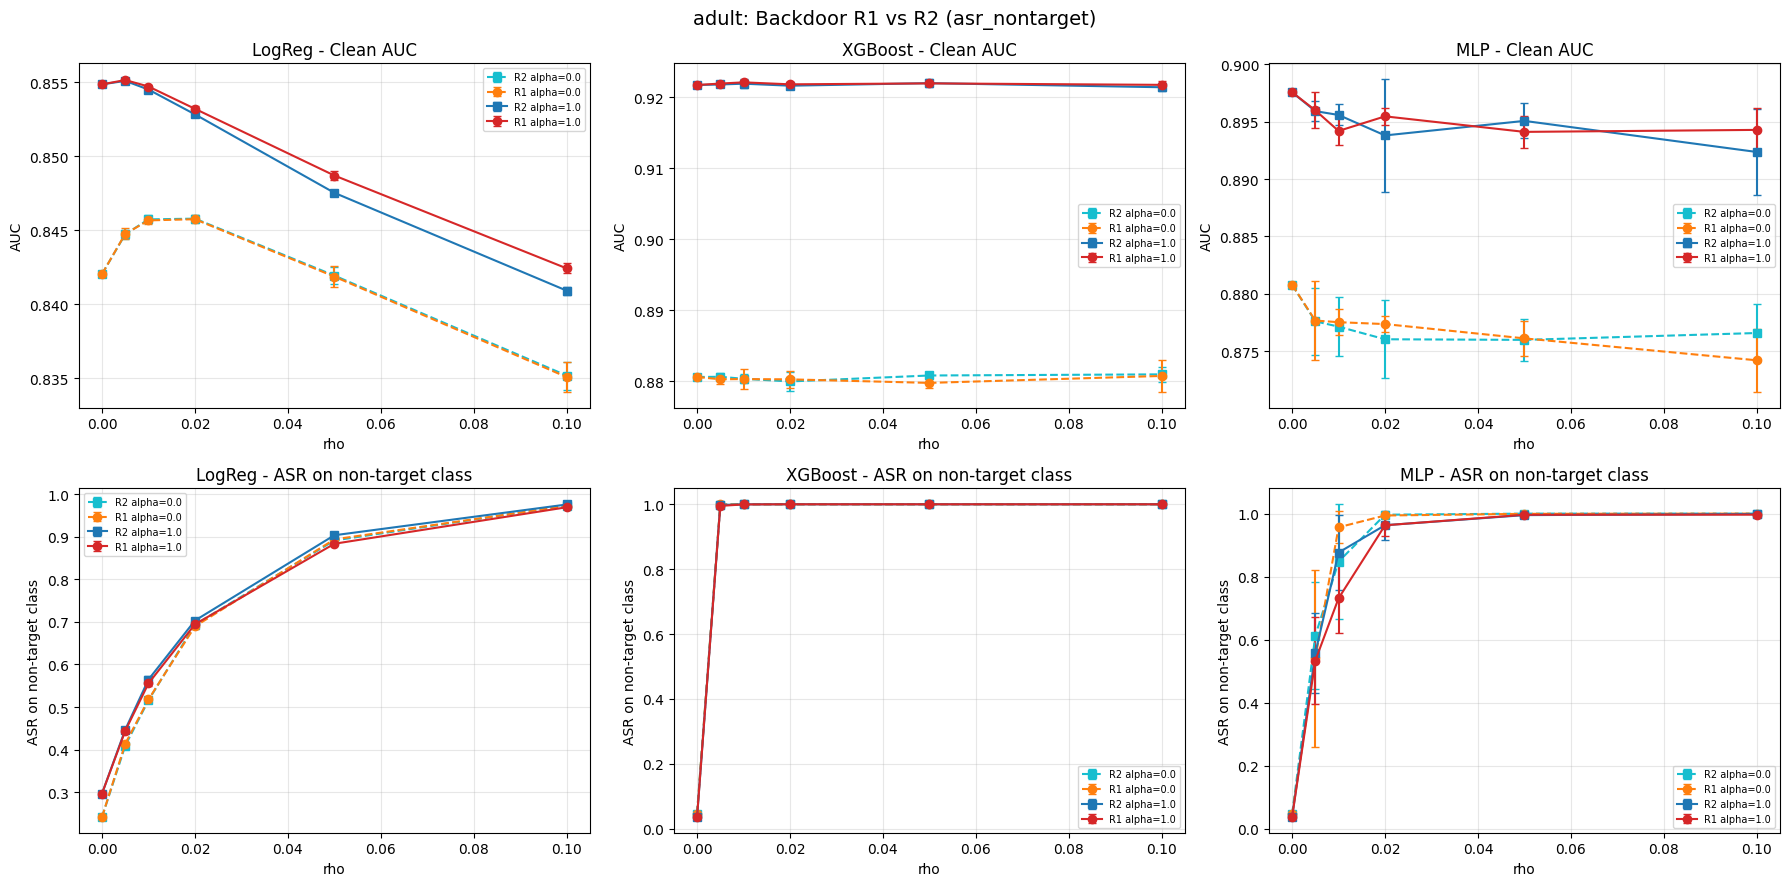

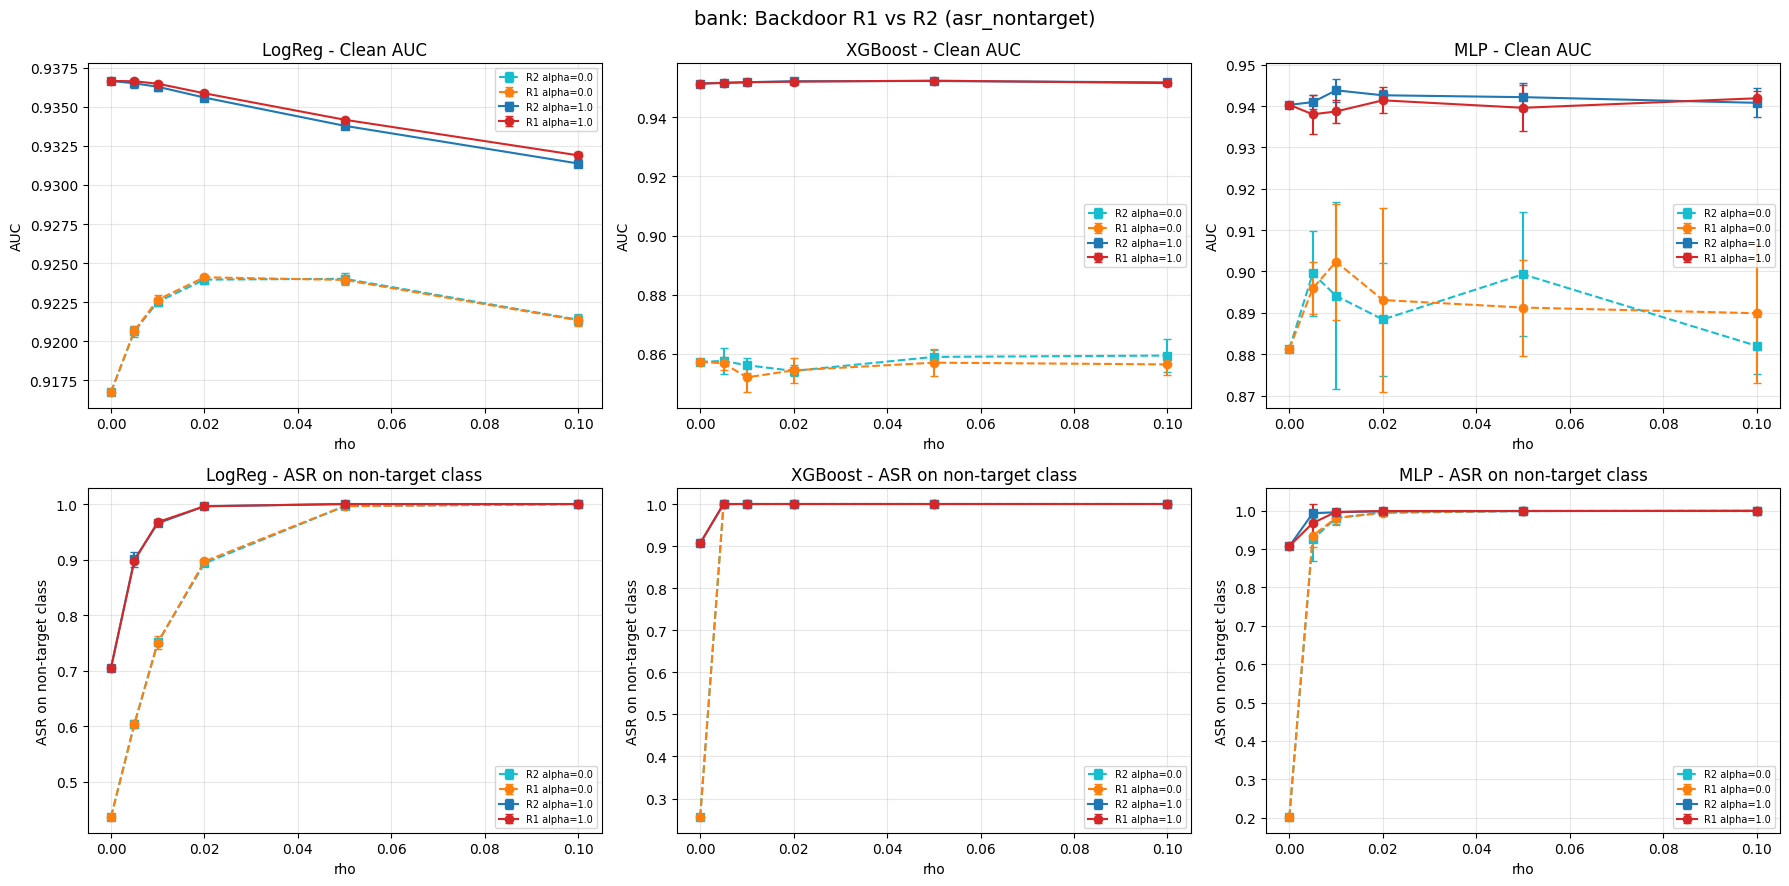

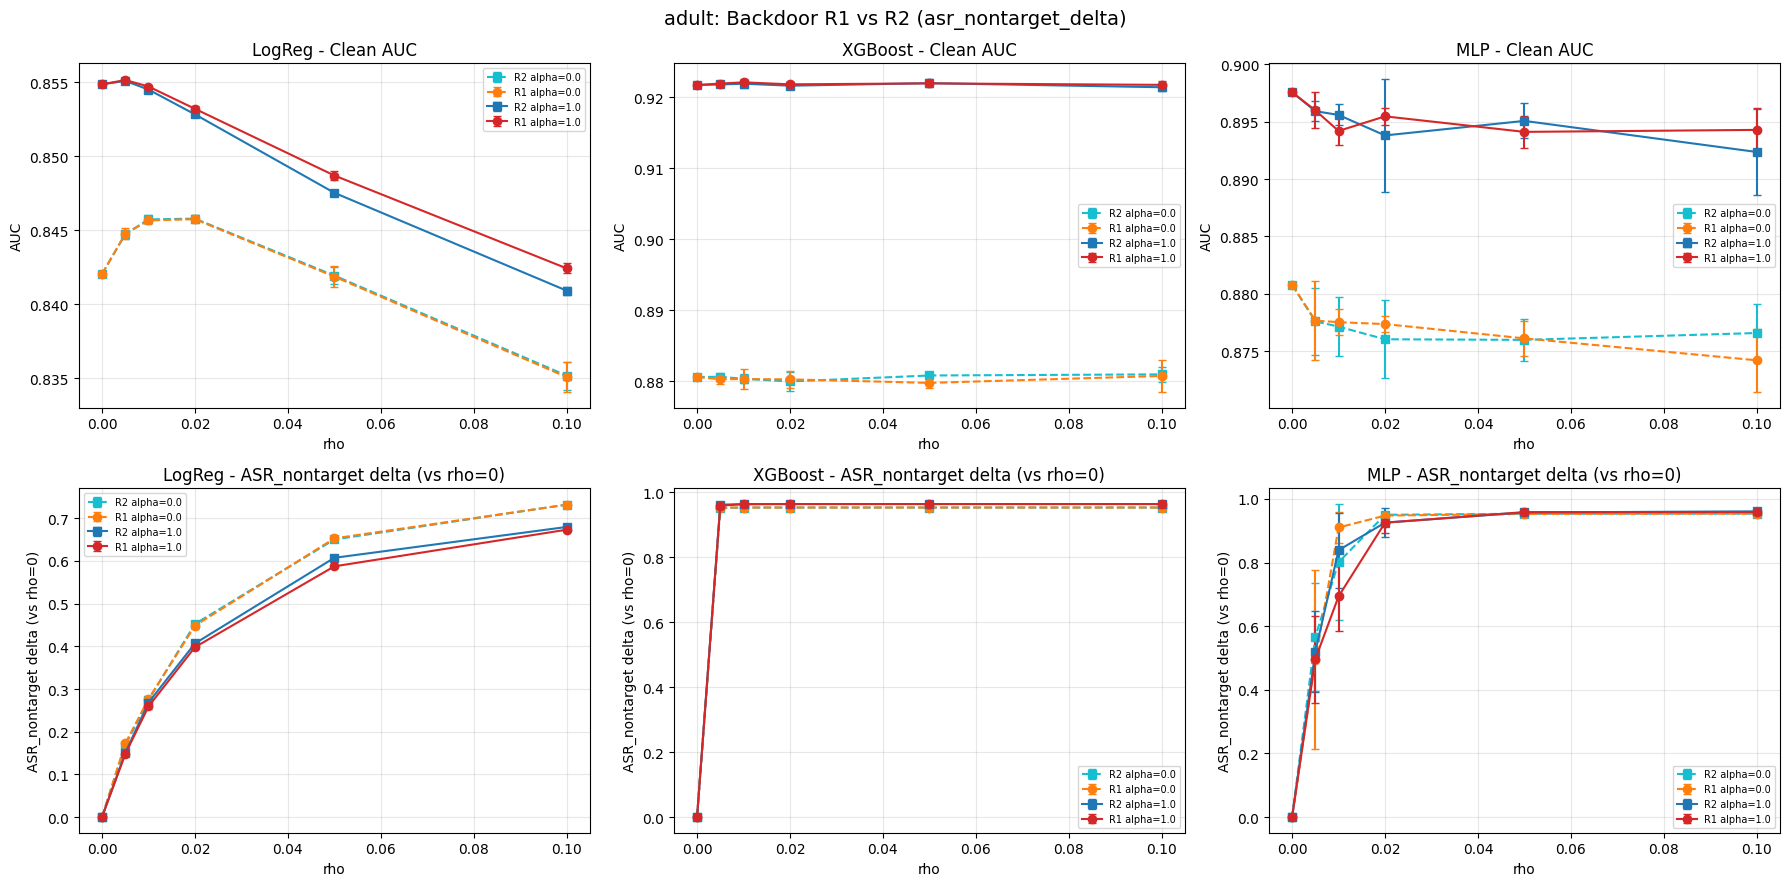

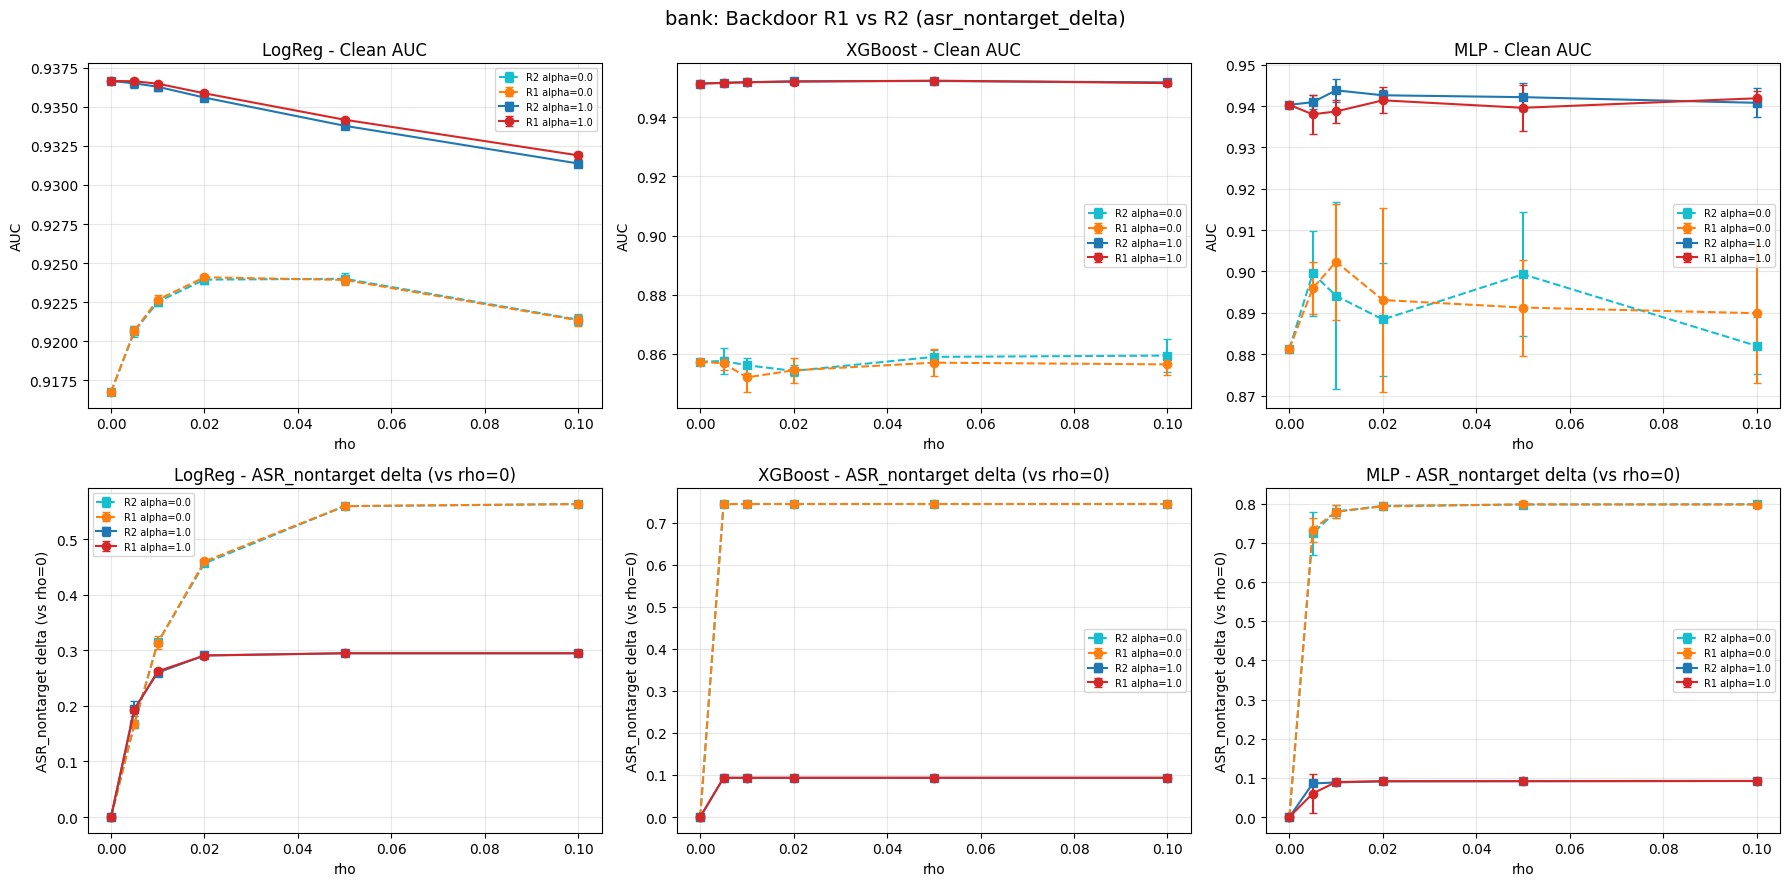

In [12]:
def plot_bd_r1_vs_r2(bd_r1_path, bd_r2_df, metric='asr_nontarget'):
    """Compare clean AUC and ASR_nontarget for backdoor across regimes.
    """
    bd_r1 = pd.read_csv('results/backdoor_all.csv') if os.path.exists('results/backdoor_all.csv') else None
    datasets = sorted(bd_r2_df['dataset'].unique())

    for name in datasets:
        r2 = bd_r2_df[bd_r2_df['dataset'] == name]
        models_to_plot = ['LogReg', 'XGBoost', 'MLP']
        fig, axes = plt.subplots(2, len(models_to_plot), figsize=(6*len(models_to_plot), 9))

        for j, mname in enumerate(models_to_plot):
            for alpha in [0.0, 1.0]:
                # R2
                s = r2[(r2['model']==mname) & (r2['alpha']==alpha)]
                auc_agg = s.groupby('rho')['test_auc'].agg(['mean','std']).reset_index()
                asr_agg = s.groupby('rho')[metric].agg(['mean','std']).reset_index()
                color_r2 = 'tab:blue' if alpha == 1.0 else 'tab:cyan'
                ls = '-' if alpha == 1.0 else '--'
                axes[0, j].errorbar(auc_agg['rho'], auc_agg['mean'], yerr=auc_agg['std'],
                                    marker='s', capsize=3, color=color_r2, linestyle=ls,
                                    label=f'R2 alpha={alpha:.1f}')
                axes[1, j].errorbar(asr_agg['rho'], asr_agg['mean'], yerr=asr_agg['std'],
                                    marker='s', capsize=3, color=color_r2, linestyle=ls,
                                    label=f'R2 alpha={alpha:.1f}')

                # R1 overlay (if available)
                if bd_r1 is not None and metric in bd_r1.columns:
                    s1 = bd_r1[(bd_r1['dataset']==name) & (bd_r1['model']==mname) & (bd_r1['alpha']==alpha)]
                    if len(s1):
                        auc1 = s1.groupby('rho')['test_auc'].agg(['mean','std']).reset_index()
                        asr1 = s1.groupby('rho')[metric].agg(['mean','std']).reset_index()
                        color_r1 = 'tab:red' if alpha == 1.0 else 'tab:orange'
                        axes[0, j].errorbar(auc1['rho'], auc1['mean'], yerr=auc1['std'],
                                            marker='o', capsize=3, color=color_r1, linestyle=ls,
                                            label=f'R1 alpha={alpha:.1f}')
                        axes[1, j].errorbar(asr1['rho'], asr1['mean'], yerr=asr1['std'],
                                            marker='o', capsize=3, color=color_r1, linestyle=ls,
                                            label=f'R1 alpha={alpha:.1f}')

            axes[0, j].set_title(f'{mname} - Clean AUC')
            axes[0, j].set_xlabel('rho'); axes[0, j].set_ylabel('AUC')
            axes[0, j].legend(fontsize=7); axes[0, j].grid(True, alpha=0.3)

            metric_label = {
                'asr': 'ASR (full)',
                'asr_nontarget': 'ASR on non-target class',
                'asr_delta': 'ASR delta (vs rho=0)',
                'asr_nontarget_delta': 'ASR_nontarget delta (vs rho=0)',
            }.get(metric, metric)
            axes[1, j].set_title(f'{mname} - {metric_label}')
            axes[1, j].set_xlabel('rho'); axes[1, j].set_ylabel(metric_label)
            axes[1, j].legend(fontsize=7); axes[1, j].grid(True, alpha=0.3)

        plt.suptitle(f'{name}: Backdoor R1 vs R2 ({metric})', fontsize=14)
        plt.tight_layout()
        plt.savefig(f'figures/regime2/{name}_bd_r1_vs_r2_{metric}.png', dpi=150, bbox_inches='tight')
        plt.show()

# Главный график - ASR на нецелевом классе
plot_bd_r1_vs_r2('results/backdoor_all.csv', bd_r2, metric='asr_nontarget')

# Дополнительно: baseline-adjusted версия (показывает чистый эффект атаки)
plot_bd_r1_vs_r2('results/backdoor_all.csv', bd_r2, metric='asr_nontarget_delta')

In [13]:
# ============================================================
# Spectral Filtering защита для BD Режим 2 (MLP)
# ============================================================
from sklearn.neural_network import MLPClassifier
from joblib import Parallel, delayed

def get_mlp_representations(X, y, seed=SEED):
    mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                       early_stopping=True, random_state=seed, verbose=False)
    mlp.fit(X, y)
    activations = X.copy()
    penultimate = None
    for i, (W, b) in enumerate(zip(mlp.coefs_, mlp.intercepts_)):
        activations = activations @ W + b
        if i < len(mlp.coefs_) - 1:
            activations = np.maximum(activations, 0)
        if i == len(mlp.coefs_) - 2:
            penultimate = activations.copy()
            break
    return mlp, penultimate

def spectral_filter(X, y, penultimate, top_k_pct=0.05):
    centered = penultimate - penultimate.mean(axis=0)
    U, S, Vt = np.linalg.svd(centered, full_matrices=False)
    top_v = Vt[0]
    scores = np.abs(centered @ top_v)
    n_remove = int(top_k_pct * len(X))
    threshold = np.sort(scores)[-n_remove] if n_remove > 0 else np.inf
    mask = scores < threshold
    return X[mask], y[mask], mask


def compute_asr_metrics(model, X_test, y_test, X_test_trig, target_label):
    preds_trig = model.predict(X_test_trig)
    asr_full = (preds_trig == target_label).mean()
    nontarget_mask = (y_test != target_label)
    asr_nontarget = (preds_trig[nontarget_mask] == target_label).mean() if nontarget_mask.sum() > 0 else float('nan')
    return asr_full, asr_nontarget


def spectral_r2_one_seed(seed, alpha, rho, X_train, y_train, X_poison_raw,
                         trigger_cols, trigger_vals, target_label,
                         X_test, X_test_trig, y_test, name):
    """Один seed: атака BD-R2 + (защита или без) + оценка."""
    if rho == 0.0 or X_poison_raw is None:
        X_tr, y_tr = X_train.copy(), y_train.copy()
    else:
        X_p_trig = apply_trigger(X_poison_raw, trigger_cols, trigger_vals)
        y_p_target = np.full(len(X_p_trig), target_label, dtype=int)
        X_tr, y_tr = inject_synthetic_poison(X_train, y_train, X_p_trig, y_p_target, rho, seed)

    rows = []
    for defended in [False, True]:
        if defended:
            _, penult = get_mlp_representations(X_tr, y_tr, seed)
            X_d, y_d, _ = spectral_filter(X_tr, y_tr, penult)
        else:
            X_d, y_d = X_tr, y_tr

        mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                            early_stopping=True, random_state=seed, verbose=False)
        mlp.fit(X_d, y_d)
        auc = roc_auc_score(y_test, mlp.predict_proba(X_test)[:, 1])
        asr_full, asr_nontarget = compute_asr_metrics(
            mlp, X_test, y_test, X_test_trig, target_label)
        rows.append({
            'dataset': name, 'regime': 'R2', 'alpha': alpha, 'attack': 'BD-R2',
            'defense': 'spectral' if defended else 'none',
            'rho': rho, 'seed': seed, 'model': 'MLP',
            'test_auc': auc, 'asr': asr_full, 'asr_nontarget': asr_nontarget,
        })
    return rows


def run_spectral_r2(name, target_label=1):
    ds_state = DS_STATE[name]
    meta = ds_state['meta']
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')

    trigger_cols = meta['num_idx'][:2] if len(meta['num_idx']) >= 2 else meta['num_idx']
    trigger_vals = [3.0] * len(trigger_cols)
    X_test_trig = apply_trigger(X_test, trigger_cols, trigger_vals)

    all_results = []
    for alpha in [0.0, 0.5, 1.0]:
        tag = f'alpha_{alpha:.2f}'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')
        n_train = len(X_train)

        for rho in [0.0, 0.02, 0.05, 0.10]:
            n_poison = int(rho * n_train)
            poison_by_seed = {}
            for seed in SEEDS:
                if n_poison > 0:
                    X_p_raw, _ = sample_synthetic_poison(name, n_poison, seed, ds_state)
                    poison_by_seed[seed] = X_p_raw
                else:
                    poison_by_seed[seed] = None

            seed_results = Parallel(n_jobs=-1, verbose=0)(
                delayed(spectral_r2_one_seed)(
                    seed, alpha, rho, X_train, y_train, poison_by_seed[seed],
                    trigger_cols, trigger_vals, target_label,
                    X_test, X_test_trig, y_test, name)
                for seed in SEEDS)
            for rows in seed_results:
                all_results.extend(rows)
            print(f'  [{name}] spectral R2 alpha={alpha:.2f} rho={rho:.3f} done')

    df = pd.DataFrame(all_results)
    # Baseline-adjusted метрики
    df['asr_delta'] = float('nan')
    df['asr_nontarget_delta'] = float('nan')
    for (a, d), sub in df.groupby(['alpha', 'defense']):
        clean_full = sub.loc[sub['rho'] == 0.0, 'asr'].mean()
        clean_nt   = sub.loc[sub['rho'] == 0.0, 'asr_nontarget'].mean()
        mask = (df['alpha'] == a) & (df['defense'] == d)
        df.loc[mask, 'asr_delta']           = df.loc[mask, 'asr'] - clean_full
        df.loc[mask, 'asr_nontarget_delta'] = df.loc[mask, 'asr_nontarget'] - clean_nt
    return df


print('=== Spectral defense vs BD R2 (Adult) ===')
spec_r2 = run_spectral_r2('adult')
spec_r2.to_csv('results/regime2/defense_spectral_r2.csv', index=False)
print(f'Saved: {len(spec_r2)} rows')

=== Spectral defense vs BD R2 (Adult) ===
  [adult] spectral R2 alpha=0.00 rho=0.000 done
  [adult] spectral R2 alpha=0.00 rho=0.020 done
  [adult] spectral R2 alpha=0.00 rho=0.050 done
  [adult] spectral R2 alpha=0.00 rho=0.100 done
  [adult] spectral R2 alpha=0.50 rho=0.000 done
  [adult] spectral R2 alpha=0.50 rho=0.020 done
  [adult] spectral R2 alpha=0.50 rho=0.050 done
  [adult] spectral R2 alpha=0.50 rho=0.100 done
  [adult] spectral R2 alpha=1.00 rho=0.000 done
  [adult] spectral R2 alpha=1.00 rho=0.020 done
  [adult] spectral R2 alpha=1.00 rho=0.050 done
  [adult] spectral R2 alpha=1.00 rho=0.100 done
Saved: 120 rows


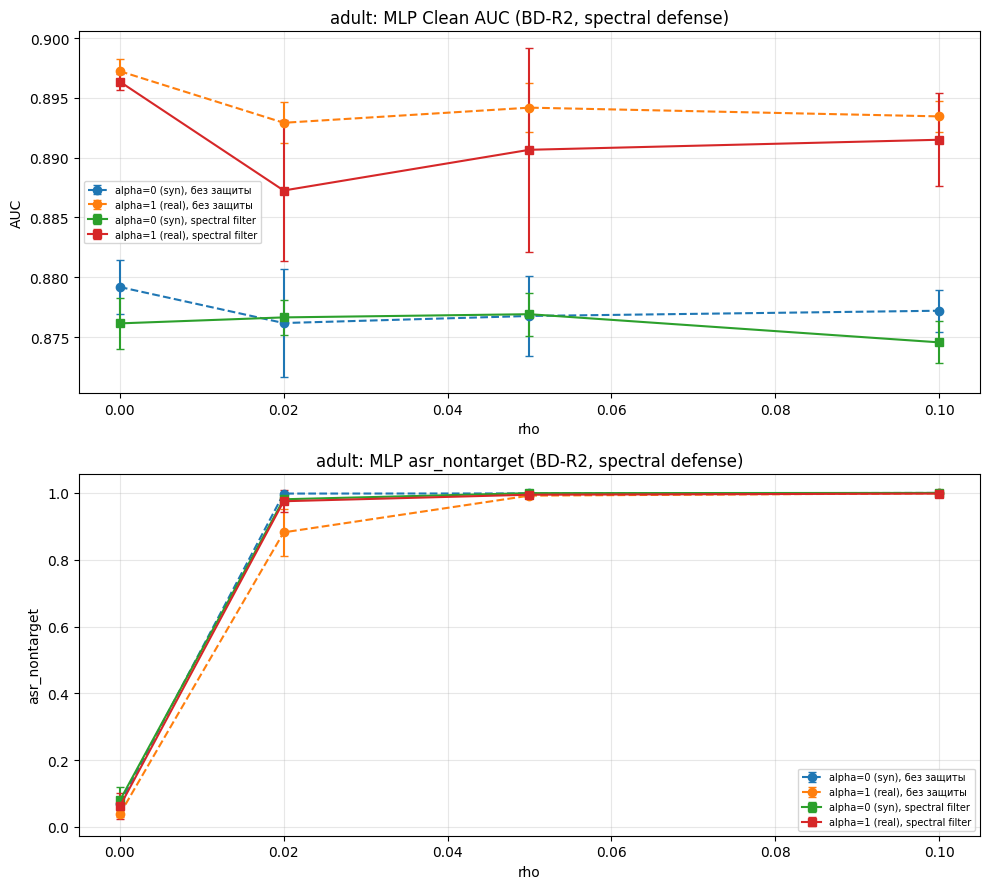

In [14]:
# График: spectral защита против BD R2 на MLP, метрика asr_nontarget
def plot_spectral_r2_defense(df, metric='asr_nontarget'):
    for name in df['dataset'].unique():
        ds = df[df['dataset'] == name]
        fig, axes = plt.subplots(2, 1, figsize=(10, 9))

        for defended, ls, marker, lbl in [('none', '--', 'o', 'без защиты'),
                                           ('spectral', '-', 's', 'spectral filter')]:
            for alpha in [0.0, 1.0]:
                sub = ds[(ds['defense']==defended) & (ds['alpha']==alpha)]
                tag = f'alpha={alpha:.0f} ({"real" if alpha==1.0 else "syn"}), {lbl}'

                auc_agg = sub.groupby('rho')['test_auc'].agg(['mean','std']).reset_index()
                axes[0].errorbar(auc_agg['rho'], auc_agg['mean'], yerr=auc_agg['std'],
                                 marker=marker, capsize=3, linestyle=ls, label=tag)

                asr_agg = sub.groupby('rho')[metric].agg(['mean','std']).reset_index()
                axes[1].errorbar(asr_agg['rho'], asr_agg['mean'], yerr=asr_agg['std'],
                                 marker=marker, capsize=3, linestyle=ls, label=tag)

        axes[0].set_title(f'{name}: MLP Clean AUC (BD-R2, spectral defense)')
        axes[0].set_xlabel('rho'); axes[0].set_ylabel('AUC')
        axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

        axes[1].set_title(f'{name}: MLP {metric} (BD-R2, spectral defense)')
        axes[1].set_xlabel('rho'); axes[1].set_ylabel(metric)
        axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'figures/regime2/{name}_spectral_r2_{metric}.png', dpi=150, bbox_inches='tight')
        plt.show()

plot_spectral_r2_defense(spec_r2, metric='asr_nontarget')

In [15]:
# ============================================================
# Sanitize и Cleanlab защиты для LF Режим 2
# ============================================================
from sklearn.covariance import EllipticEnvelope
from joblib import Parallel, delayed

def sanitize(X, y, contamination=0.05, seed=SEED):
    try:
        det = EllipticEnvelope(contamination=contamination, random_state=seed)
        preds = det.fit_predict(X)
        mask = preds == 1
    except Exception:
        mask = np.ones(len(X), dtype=bool)
    return X[mask], y[mask], mask

def sanitize_def(X, y, seed=SEED):
    return sanitize(X, y, contamination=0.05, seed=seed)

try:
    from cleanlab.filter import find_label_issues
    from sklearn.model_selection import cross_val_predict

    def cleanlab_def(X, y, seed=SEED):
        try:
            lr = LogisticRegression(max_iter=1000, random_state=seed)
            pred_probs = cross_val_predict(lr, X, y, cv=3, method='predict_proba')
            issue_idx = find_label_issues(y, pred_probs, return_indices_ranked_by='self_confidence')
            n_remove = min(len(issue_idx), int(0.1 * len(y)))
            remove_set = set(issue_idx[:n_remove])
            mask = np.array([i not in remove_set for i in range(len(y))])
        except Exception as e:
            print(f'  cleanlab failed: {e}')
            mask = np.ones(len(y), dtype=bool)
        return X[mask], y[mask], mask
    HAS_CLEANLAB = True
except ImportError:
    HAS_CLEANLAB = False
    print('cleanlab not installed, will skip')


def lf_r2_defense_one_seed(seed, alpha, rho, X_train, y_train,
                           X_poison, y_poison, defense_fn, defense_name,
                           X_test, y_test, name):
    if rho == 0.0 or X_poison is None:
        X_atk, y_atk = X_train.copy(), y_train.copy()
    else:
        y_p_flipped = 1 - y_poison
        X_atk, y_atk = inject_synthetic_poison(X_train, y_train, X_poison, y_p_flipped, rho, seed)

    rows = []
    for defended in [False, True]:
        if defended:
            X_tr, y_tr, _ = defense_fn(X_atk, y_atk, seed=seed)
        else:
            X_tr, y_tr = X_atk, y_atk
        for mname, model in get_core_models().items():
            model.fit(X_tr, y_tr)
            auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
            rows.append({'dataset': name, 'regime': 'R2', 'attack': 'LF-R2',
                         'defense': defense_name if defended else 'none',
                         'alpha': alpha, 'rho': rho, 'seed': seed,
                         'model': mname, 'test_auc': auc})
    return rows


def run_lf_r2_defense(name, defense_fn, defense_name):
    ds_state = DS_STATE[name]
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')

    all_results = []
    for alpha in [0.0, 0.5, 1.0]:
        tag = f'alpha_{alpha:.2f}'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')
        n_train = len(X_train)

        for rho in [0.0, 0.02, 0.05, 0.10]:
            n_poison = int(rho * n_train)
            poison_by_seed = {}
            for seed in SEEDS:
                if n_poison > 0:
                    poison_by_seed[seed] = sample_synthetic_poison(name, n_poison, seed, ds_state)
                else:
                    poison_by_seed[seed] = (None, None)

            seed_results = Parallel(n_jobs=-1, verbose=0)(
                delayed(lf_r2_defense_one_seed)(
                    seed, alpha, rho, X_train, y_train,
                    poison_by_seed[seed][0], poison_by_seed[seed][1],
                    defense_fn, defense_name, X_test, y_test, name)
                for seed in SEEDS)
            for rows in seed_results:
                all_results.extend(rows)
            print(f'  [{name}] LF-R2+{defense_name} alpha={alpha:.2f} rho={rho:.3f} done')
    return pd.DataFrame(all_results)


print('=== Sanitize vs LF R2 (Adult) ===')
san_lf_r2 = run_lf_r2_defense('adult', sanitize_def, 'sanitize')
san_lf_r2.to_csv('results/regime2/defense_sanitize_lf_r2.csv', index=False)

if HAS_CLEANLAB:
    print('\n=== Cleanlab vs LF R2 (Adult) ===')
    cl_lf_r2 = run_lf_r2_defense('adult', cleanlab_def, 'cleanlab')
    cl_lf_r2.to_csv('results/regime2/defense_cleanlab_lf_r2.csv', index=False)
else:
    cl_lf_r2 = pd.DataFrame()

print(f'\nSanitize: {len(san_lf_r2)} rows, Cleanlab: {len(cl_lf_r2)} rows')

cleanlab not installed, will skip
=== Sanitize vs LF R2 (Adult) ===
  [adult] LF-R2+sanitize alpha=0.00 rho=0.000 done
  [adult] LF-R2+sanitize alpha=0.00 rho=0.020 done
  [adult] LF-R2+sanitize alpha=0.00 rho=0.050 done
  [adult] LF-R2+sanitize alpha=0.00 rho=0.100 done
  [adult] LF-R2+sanitize alpha=0.50 rho=0.000 done
  [adult] LF-R2+sanitize alpha=0.50 rho=0.020 done
  [adult] LF-R2+sanitize alpha=0.50 rho=0.050 done
  [adult] LF-R2+sanitize alpha=0.50 rho=0.100 done
  [adult] LF-R2+sanitize alpha=1.00 rho=0.000 done
  [adult] LF-R2+sanitize alpha=1.00 rho=0.020 done
  [adult] LF-R2+sanitize alpha=1.00 rho=0.050 done
  [adult] LF-R2+sanitize alpha=1.00 rho=0.100 done

Sanitize: 240 rows, Cleanlab: 0 rows


In [16]:
# ============================================================
# Sanitize защита для FP Режим 2
# ============================================================
def fp_r2_defense_one_seed(seed, alpha, rho, lam, X_train, y_train,
                           X_poison_raw, y_poison_raw, meta,
                           defense_fn, defense_name,
                           X_test, y_test, name):
    if rho == 0.0 or X_poison_raw is None:
        X_atk, y_atk = X_train.copy(), y_train.copy()
    else:
        X_p = X_poison_raw.copy()
        rng = np.random.RandomState(seed)
        if len(meta['num_idx']) > 0:
            noise = rng.normal(0, lam, size=(len(X_p), len(meta['num_idx'])))
            X_p[:, meta['num_idx']] += noise
        if len(meta['cat_idx']) > 0:
            for i in range(len(X_p)):
                col = rng.choice(meta['cat_idx'])
                vals = np.unique(X_train[:, col])
                X_p[i, col] = rng.choice(vals)
        X_atk, y_atk = inject_synthetic_poison(X_train, y_train, X_p, y_poison_raw, rho, seed)

    rows = []
    for defended in [False, True]:
        if defended:
            X_tr, y_tr, _ = defense_fn(X_atk, y_atk, seed=seed)
        else:
            X_tr, y_tr = X_atk, y_atk
        for mname, model in get_core_models().items():
            model.fit(X_tr, y_tr)
            auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
            rows.append({'dataset': name, 'regime': 'R2', 'attack': 'FP-R2',
                         'defense': defense_name if defended else 'none',
                         'alpha': alpha, 'rho': rho, 'lambda': lam, 'seed': seed,
                         'model': mname, 'test_auc': auc})
    return rows


def run_fp_r2_defense(name, defense_fn, defense_name, lam=1.0):
    ds_state = DS_STATE[name]
    meta = ds_state['meta']
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')

    all_results = []
    for alpha in [0.0, 0.5, 1.0]:
        tag = f'alpha_{alpha:.2f}'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')
        n_train = len(X_train)

        for rho in [0.0, 0.02, 0.05, 0.10]:
            n_poison = int(rho * n_train)
            poison_by_seed = {}
            for seed in SEEDS:
                if n_poison > 0:
                    poison_by_seed[seed] = sample_synthetic_poison(name, n_poison, seed, ds_state)
                else:
                    poison_by_seed[seed] = (None, None)

            seed_results = Parallel(n_jobs=-1, verbose=0)(
                delayed(fp_r2_defense_one_seed)(
                    seed, alpha, rho, lam, X_train, y_train,
                    poison_by_seed[seed][0], poison_by_seed[seed][1], meta,
                    defense_fn, defense_name, X_test, y_test, name)
                for seed in SEEDS)
            for rows in seed_results:
                all_results.extend(rows)
            print(f'  [{name}] FP-R2+{defense_name} alpha={alpha:.2f} rho={rho:.3f} lambda={lam} done')
    return pd.DataFrame(all_results)


print('=== Sanitize vs FP R2 (Adult, lambda=1.0) ===')
san_fp_r2 = run_fp_r2_defense('adult', sanitize_def, 'sanitize', lam=1.0)
san_fp_r2.to_csv('results/regime2/defense_sanitize_fp_r2.csv', index=False)
print(f'\nSanitize FP-R2: {len(san_fp_r2)} rows')

=== Sanitize vs FP R2 (Adult, lambda=1.0) ===
  [adult] FP-R2+sanitize alpha=0.00 rho=0.000 lambda=1.0 done
  [adult] FP-R2+sanitize alpha=0.00 rho=0.020 lambda=1.0 done
  [adult] FP-R2+sanitize alpha=0.00 rho=0.050 lambda=1.0 done
  [adult] FP-R2+sanitize alpha=0.00 rho=0.100 lambda=1.0 done
  [adult] FP-R2+sanitize alpha=0.50 rho=0.000 lambda=1.0 done
  [adult] FP-R2+sanitize alpha=0.50 rho=0.020 lambda=1.0 done
  [adult] FP-R2+sanitize alpha=0.50 rho=0.050 lambda=1.0 done
  [adult] FP-R2+sanitize alpha=0.50 rho=0.100 lambda=1.0 done
  [adult] FP-R2+sanitize alpha=1.00 rho=0.000 lambda=1.0 done
  [adult] FP-R2+sanitize alpha=1.00 rho=0.020 lambda=1.0 done
  [adult] FP-R2+sanitize alpha=1.00 rho=0.050 lambda=1.0 done
  [adult] FP-R2+sanitize alpha=1.00 rho=0.100 lambda=1.0 done

Sanitize FP-R2: 240 rows


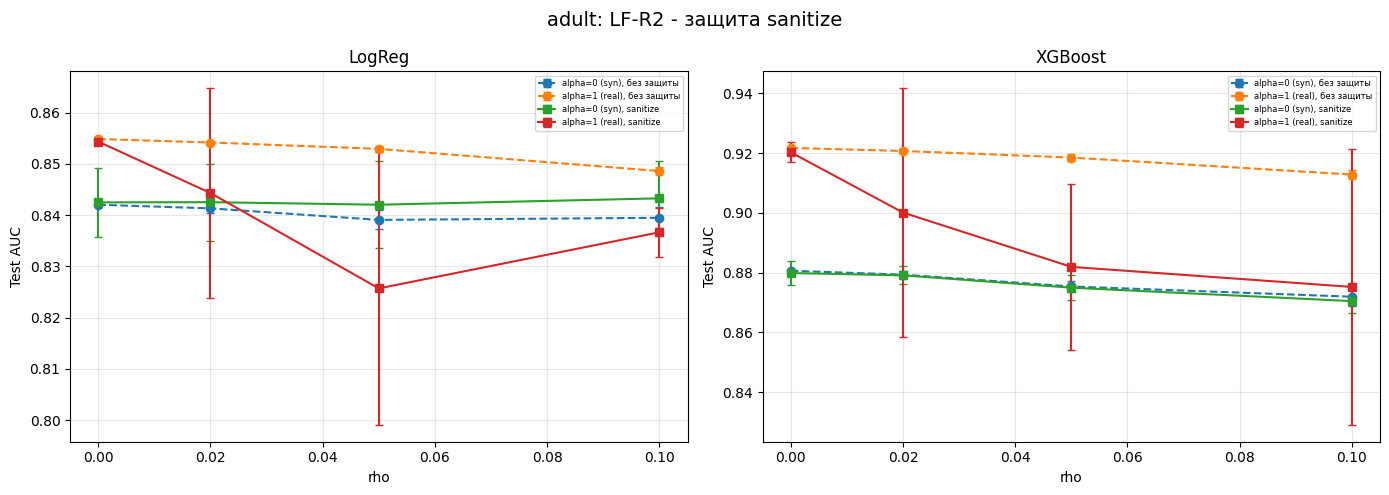

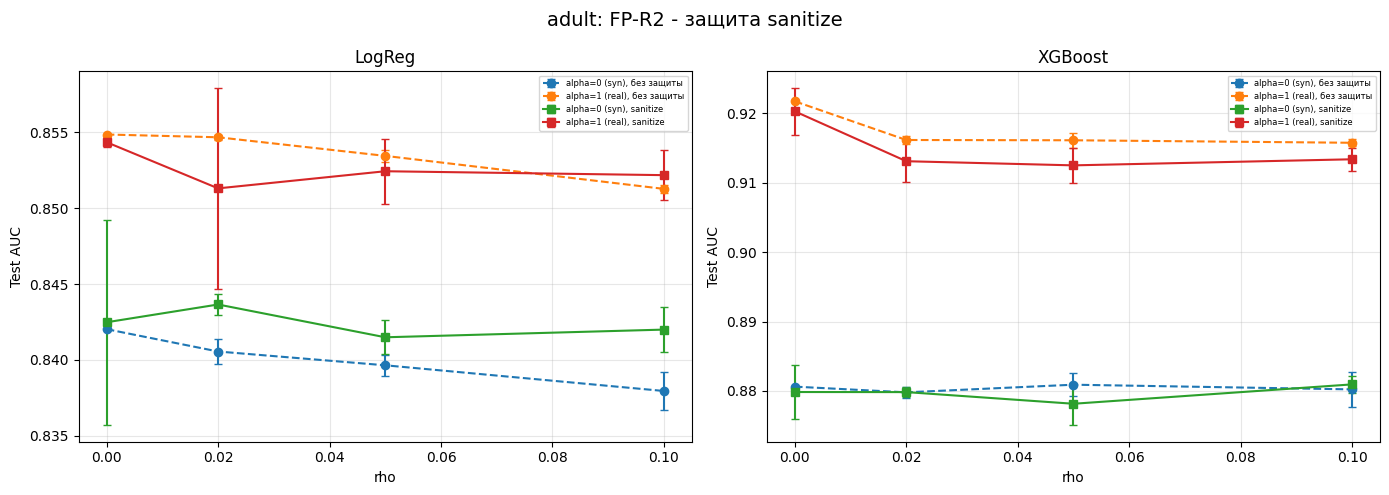

In [17]:
def plot_r2_defense(df, attack_name, defense_name):
    for name in df['dataset'].unique():
        ds = df[df['dataset'] == name]
        fig, axes = plt.subplots(1, len(CORE_MODELS), figsize=(7*len(CORE_MODELS), 5))
        if len(CORE_MODELS) == 1: axes = [axes]

        for j, mname in enumerate(CORE_MODELS):
            ms = ds[ds['model'] == mname]
            for defended, ls, marker, lbl in [('none', '--', 'o', 'без защиты'),
                                               (defense_name, '-', 's', defense_name)]:
                for alpha in [0.0, 1.0]:
                    sub = ms[(ms['defense']==defended) & (ms['alpha']==alpha)]
                    tag = f'alpha={alpha:.0f} ({"real" if alpha==1.0 else "syn"}), {lbl}'
                    agg = sub.groupby('rho')['test_auc'].agg(['mean','std']).reset_index()
                    axes[j].errorbar(agg['rho'], agg['mean'], yerr=agg['std'],
                                     marker=marker, capsize=3, linestyle=ls, label=tag)
            axes[j].set_title(f'{mname}')
            axes[j].set_xlabel('rho'); axes[j].set_ylabel('Test AUC')
            axes[j].legend(fontsize=6); axes[j].grid(True, alpha=0.3)

        plt.suptitle(f'{name}: {attack_name} - защита {defense_name}', fontsize=14)
        plt.tight_layout()
        plt.savefig(f'figures/regime2/{name}_{attack_name}_{defense_name}_r2.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

plot_r2_defense(san_lf_r2, 'LF-R2', 'sanitize')
if HAS_CLEANLAB and len(cl_lf_r2) > 0:
    plot_r2_defense(cl_lf_r2, 'LF-R2', 'cleanlab')
plot_r2_defense(san_fp_r2, 'FP-R2', 'sanitize')

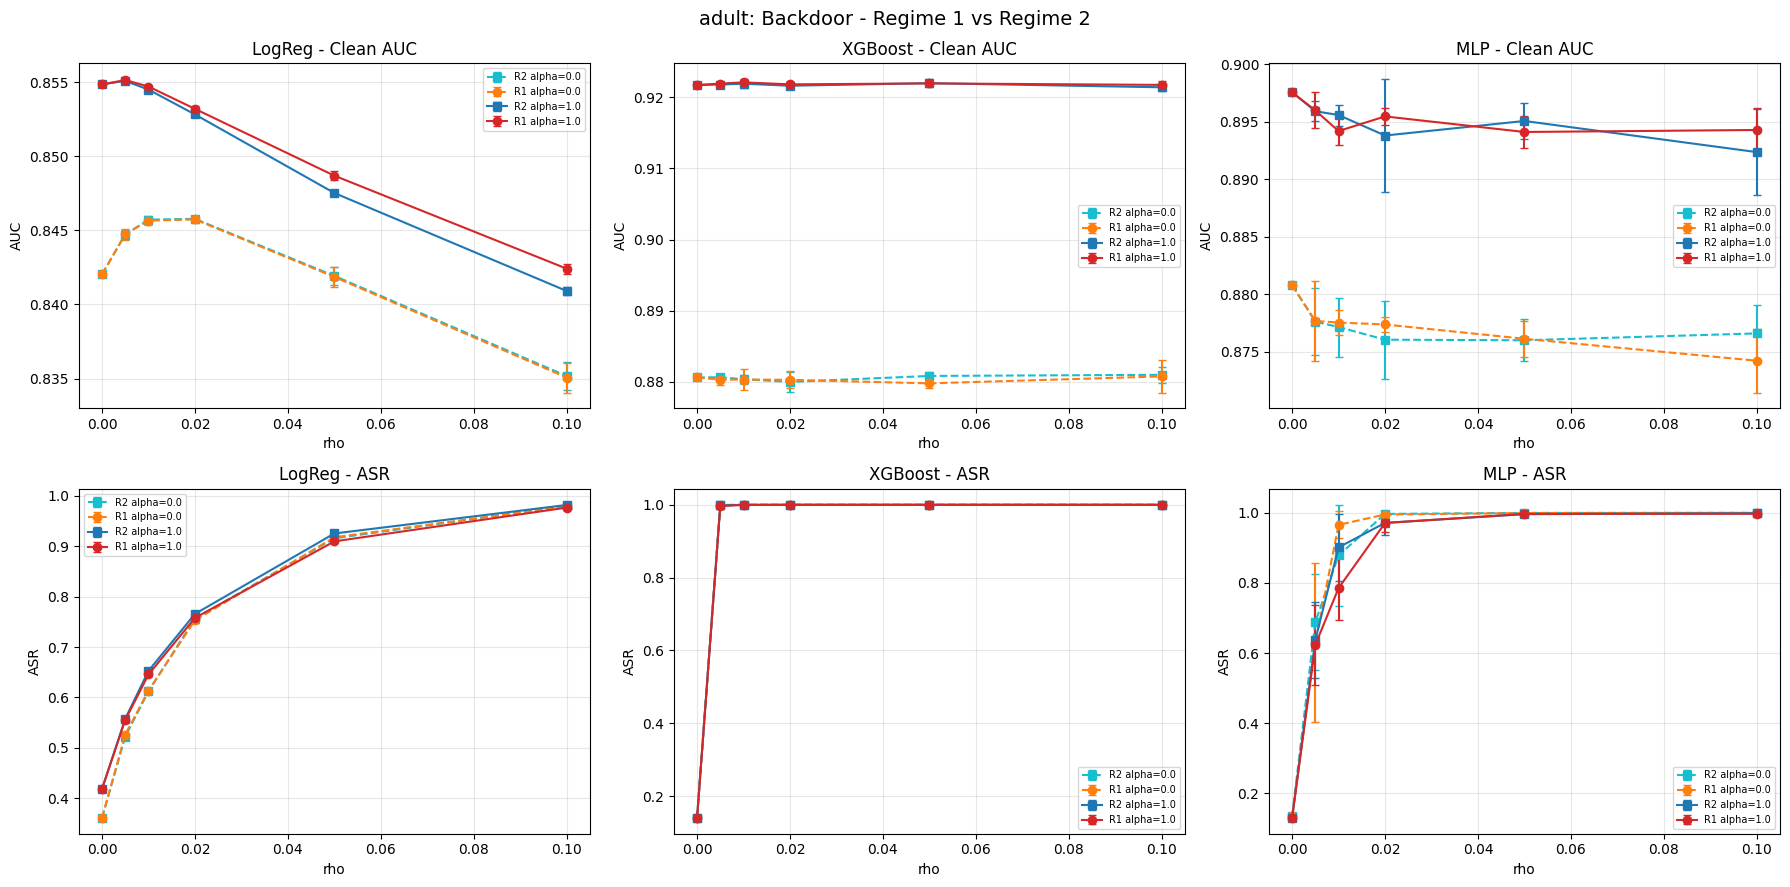

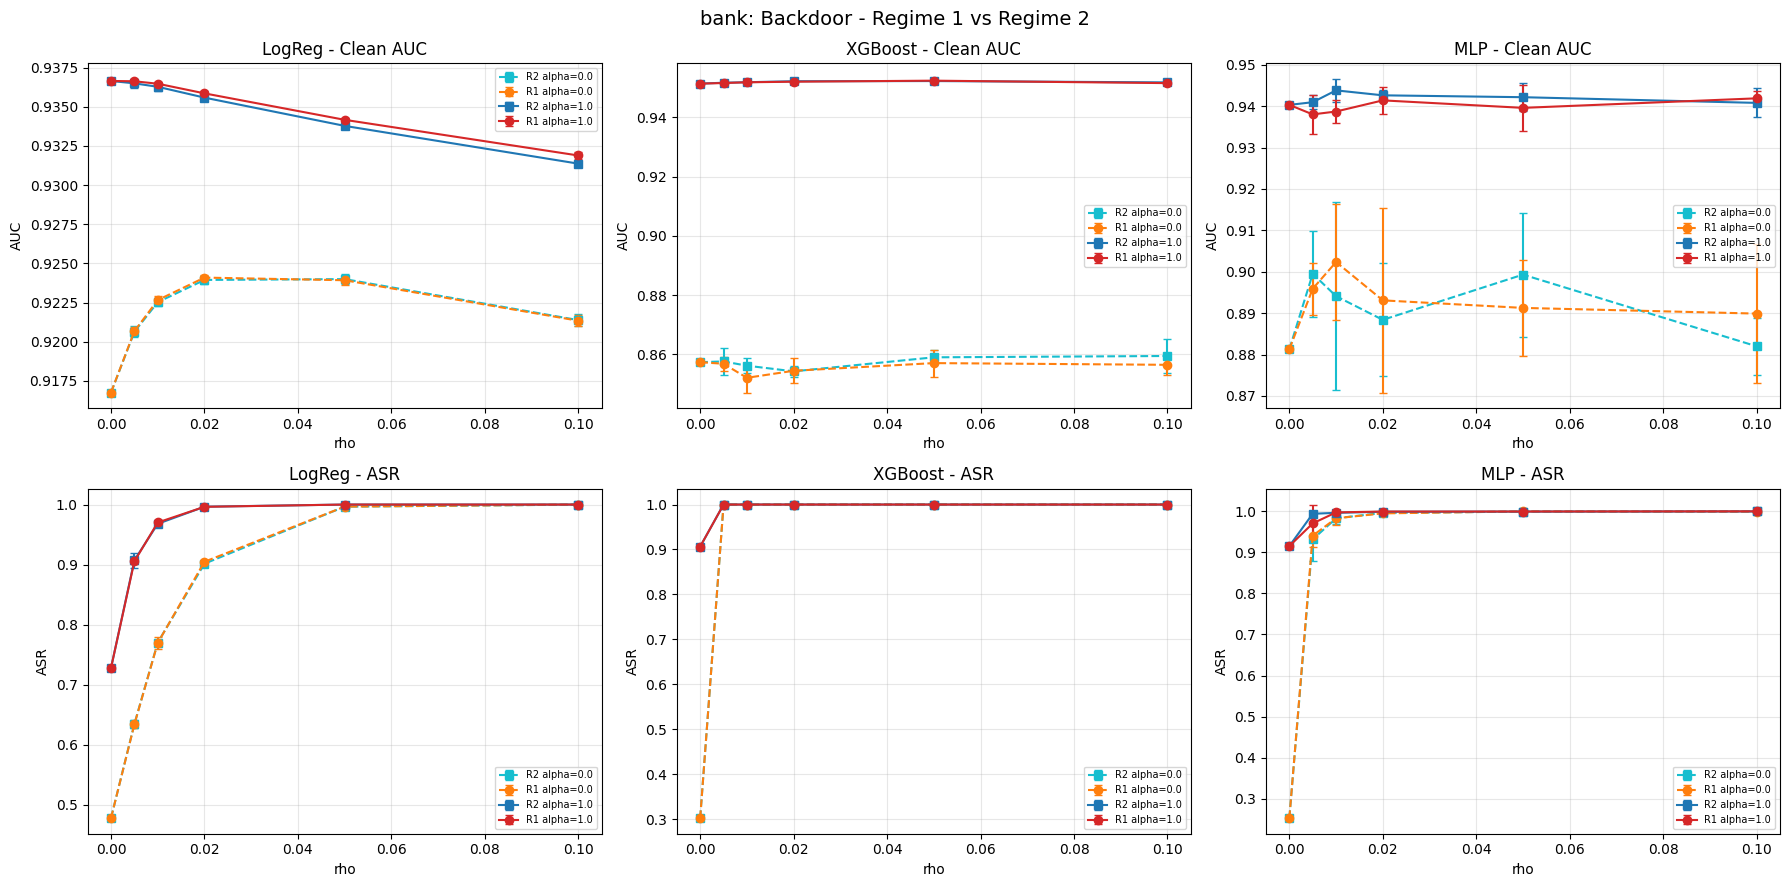

In [10]:
def plot_bd_r1_vs_r2(bd_r1_path, bd_r2_df):
    """Compare ASR and clean AUC for backdoor across regimes."""
    bd_r1 = pd.read_csv('results/backdoor_all.csv') if os.path.exists('results/backdoor_all.csv') else None

    datasets = sorted(bd_r2_df['dataset'].unique())
    for name in datasets:
        r2 = bd_r2_df[bd_r2_df['dataset'] == name]
        models_to_plot = ['LogReg', 'XGBoost', 'MLP']

        fig, axes = plt.subplots(2, len(models_to_plot), figsize=(6*len(models_to_plot), 9))

        for j, mname in enumerate(models_to_plot):
            for alpha in [0.0, 1.0]:
                # R2
                s = r2[(r2['model']==mname) & (r2['alpha']==alpha)]
                auc_agg = s.groupby('rho')['test_auc'].agg(['mean','std']).reset_index()
                asr_agg = s.groupby('rho')['asr'].agg(['mean','std']).reset_index()
                color_r2 = 'tab:blue' if alpha == 1.0 else 'tab:cyan'
                ls = '-' if alpha == 1.0 else '--'
                axes[0, j].errorbar(auc_agg['rho'], auc_agg['mean'], yerr=auc_agg['std'],
                                    marker='s', capsize=3, color=color_r2, linestyle=ls,
                                    label=f'R2 alpha={alpha:.1f}')
                axes[1, j].errorbar(asr_agg['rho'], asr_agg['mean'], yerr=asr_agg['std'],
                                    marker='s', capsize=3, color=color_r2, linestyle=ls,
                                    label=f'R2 alpha={alpha:.1f}')

                # R1 overlay (if available)
                if bd_r1 is not None:
                    s1 = bd_r1[(bd_r1['dataset']==name) & (bd_r1['model']==mname) & (bd_r1['alpha']==alpha)]
                    if len(s1):
                        auc1 = s1.groupby('rho')['test_auc'].agg(['mean','std']).reset_index()
                        asr1 = s1.groupby('rho')['asr'].agg(['mean','std']).reset_index()
                        color_r1 = 'tab:red' if alpha == 1.0 else 'tab:orange'
                        axes[0, j].errorbar(auc1['rho'], auc1['mean'], yerr=auc1['std'],
                                            marker='o', capsize=3, color=color_r1, linestyle=ls,
                                            label=f'R1 alpha={alpha:.1f}')
                        axes[1, j].errorbar(asr1['rho'], asr1['mean'], yerr=asr1['std'],
                                            marker='o', capsize=3, color=color_r1, linestyle=ls,
                                            label=f'R1 alpha={alpha:.1f}')

            axes[0, j].set_title(f'{mname} - Clean AUC')
            axes[0, j].set_xlabel('rho'); axes[0, j].set_ylabel('AUC')
            axes[0, j].legend(fontsize=7); axes[0, j].grid(True, alpha=0.3)
            axes[1, j].set_title(f'{mname} - ASR')
            axes[1, j].set_xlabel('rho'); axes[1, j].set_ylabel('ASR')
            axes[1, j].legend(fontsize=7); axes[1, j].grid(True, alpha=0.3)

        plt.suptitle(f'{name}: Backdoor - Regime 1 vs Regime 2', fontsize=14)
        plt.tight_layout()
        plt.savefig(f'figures/regime2/{name}_bd_r1_vs_r2.png', dpi=150, bbox_inches='tight')
        plt.show()

plot_bd_r1_vs_r2('results/backdoor_all.csv', bd_r2)

## 9. Дельта режимов: насколько Режим 2 эффективнее (или слабее) Режима 1?

$\Delta\text{AUC}_{\text{drop}} = \text{AUC}_{\text{drop}}^{R2} - \text{AUC}_{\text{drop}}^{R1}$

Положительное значение = R2 наносит больший урон. Отрицательное = R2 слабее R1.

In [ ]:
def regime_delta_table(r1_df, r2_df, attack_r1_name, attack_r2_name, lambda_filter=None):
    """Compute delta in AUC drop between R2 and R1 at rho=10%."""
    rows = []
    for name in r1_df['dataset'].unique():
        r1 = r1_df[r1_df['dataset'] == name].copy()
        if lambda_filter is not None:
            r1 = r1[(r1.get('lambda', lambda_filter) == lambda_filter) | (r1['rho'] == 0.0)].copy()
            r1.loc[r1['rho'] == 0.0, 'lambda'] = lambda_filter

        r2 = r2_df[r2_df['dataset'] == name].copy()

        for mname in CORE_MODELS:
            for alpha in ALPHAS:
                # R1 drop
                s1_clean = r1[(r1['model']==mname) & (r1['alpha']==alpha) & (r1['rho']==0.0)]['test_auc'].mean()
                s1_worst = r1[(r1['model']==mname) & (r1['alpha']==alpha) & (r1['rho']==0.10)]['test_auc'].mean()
                drop_r1 = s1_clean - s1_worst

                # R2 drop
                s2_clean = r2[(r2['model']==mname) & (r2['alpha']==alpha) & (r2['rho']==0.0)]['test_auc'].mean()
                s2_worst = r2[(r2['model']==mname) & (r2['alpha']==alpha) & (r2['rho']==0.10)]['test_auc'].mean()
                drop_r2 = s2_clean - s2_worst

                if np.isnan(drop_r1) or np.isnan(drop_r2):
                    continue

                rows.append({
                    'dataset': name, 'model': mname, 'alpha': alpha,
                    'drop_R1': round(drop_r1, 4),
                    'drop_R2': round(drop_r2, 4),
                    'delta_R2_minus_R1': round(drop_r2 - drop_r1, 4),
                })

    df = pd.DataFrame(rows)
    print(f'\n{attack_r2_name} Regime Delta (rho=10%) ')
    print(df.to_string(index=False))
    return df

lf_delta = regime_delta_table(lf_r1, lf_r2, 'LF', 'LF-R2')
lf_delta.to_csv('results/regime2/lf_regime_delta.csv', index=False)

fp_delta = regime_delta_table(fp_r1, fp_r2, 'FP', 'FP-R2', lambda_filter=1.0)
fp_delta.to_csv('results/regime2/fp_regime_delta.csv', index=False)


LF-R2 Regime Delta (rho=10%) 
dataset   model  alpha  drop_R1  drop_R2  delta_R2_minus_R1
  adult  LogReg   0.00   0.0038   0.0031            -0.0007
  adult  LogReg   0.25   0.0055   0.0028            -0.0027
  adult  LogReg   0.50   0.0056   0.0026            -0.0030
  adult  LogReg   0.75   0.0040   0.0032            -0.0008
  adult  LogReg   1.00   0.0028   0.0057             0.0029
  adult XGBoost   0.00   0.0081   0.0089             0.0008
  adult XGBoost   0.25   0.0106   0.0055            -0.0052
  adult XGBoost   0.50   0.0091   0.0053            -0.0038
  adult XGBoost   0.75   0.0096   0.0041            -0.0054
  adult XGBoost   1.00   0.0116   0.0083            -0.0033
   bank  LogReg   0.00  -0.0042  -0.0049            -0.0008
   bank  LogReg   0.25  -0.0030  -0.0036            -0.0006
   bank  LogReg   0.50  -0.0019   0.0002             0.0021
   bank  LogReg   0.75  -0.0004   0.0063             0.0067
   bank  LogReg   1.00   0.0018   0.0182             0.0163
   bank X

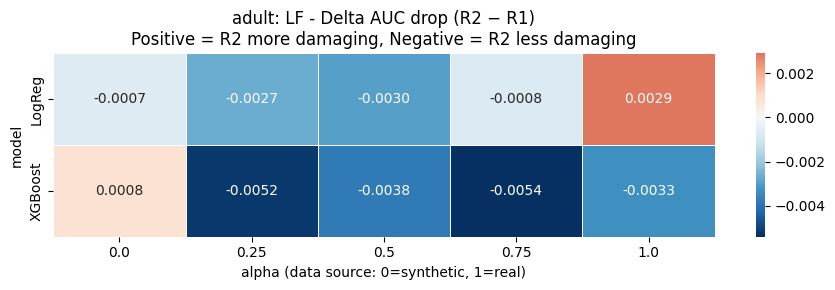

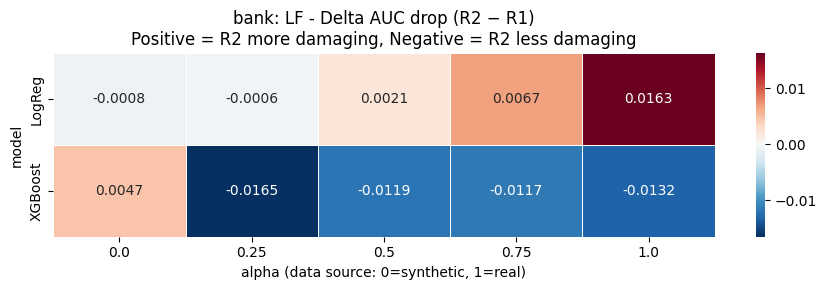

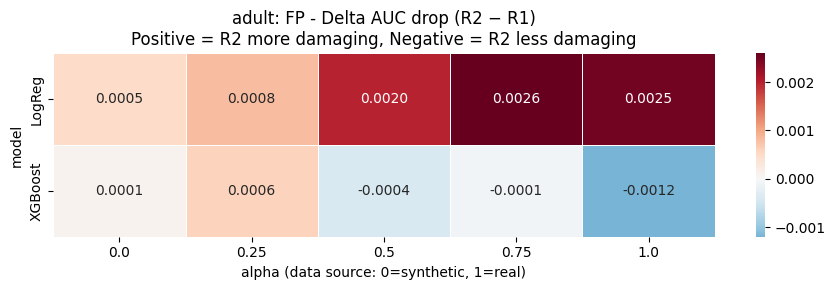

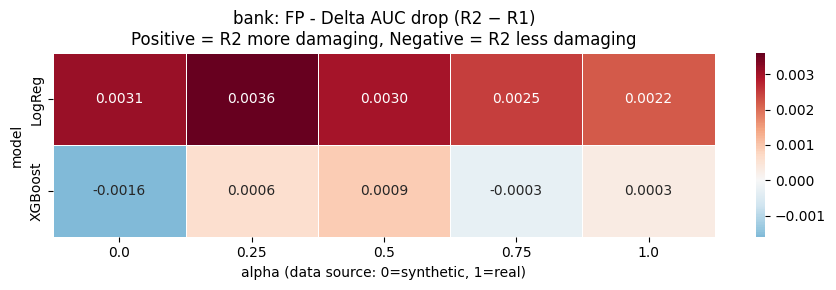

In [ ]:
# Heatmap of delta: model × alpha per dataset
def plot_delta_heatmap(delta_df, attack_label):
    for name in delta_df['dataset'].unique():
        sub = delta_df[delta_df['dataset'] == name]

        pivot = sub.pivot_table(
            index='model', columns='alpha',
            values='delta_R2_minus_R1', aggfunc='mean'
        )
        fig, ax = plt.subplots(figsize=(9, 3))
        sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdBu_r', center=0,
                    linewidths=0.5, ax=ax)
        ax.set_title(f'{name}: {attack_label} - Delta AUC drop (R2 − R1)\n'
                     f'Positive = R2 more damaging, Negative = R2 less damaging')
        ax.set_xlabel('alpha (data source: 0=synthetic, 1=real)')
        plt.tight_layout()
        plt.savefig(f'figures/regime2/{name}_{attack_label}_delta_heatmap.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

plot_delta_heatmap(lf_delta, 'LF')
plot_delta_heatmap(fp_delta, 'FP')

## 10. Regime 2 Summary Tables

AUC (mean $\pm$ std) at key poison rates, both regimes side by side.

In [ ]:
def build_r2_summary_table(df, rho_values=[0.0, 0.02, 0.05, 0.10]):
    rows = []
    for name in df['dataset'].unique():
        for mname in CORE_MODELS:
            for alpha in ALPHAS:
                sub = df[(df['dataset']==name) & (df['model']==mname) & (df['alpha']==alpha)]
                row = {'dataset': name, 'regime': 'R2', 'model': mname, 'alpha': alpha}
                for rho in rho_values:
                    vals = sub[sub['rho']==rho]['test_auc']
                    row[f'rho={rho}'] = f'{vals.mean():.4f}+/-{vals.std():.4f}' if len(vals) > 0 else '-'
                rows.append(row)
    return pd.DataFrame(rows)

print('  REGIME 2: LABEL FLIPPING')
lf_r2_table = build_r2_summary_table(lf_r2)
print(lf_r2_table.to_string(index=False))

print('\n' + '=' * 80)
print('  REGIME 2: FEATURE PERTURBATION (lambda=1.0)')
fp_r2_lam1 = fp_r2[(fp_r2['lambda'].isin([1.0, 0.0]))].copy()
fp_r2_lam1.loc[fp_r2_lam1['rho'] == 0.0, 'lambda'] = 1.0
fp_r2_table = build_r2_summary_table(fp_r2_lam1)
print(fp_r2_table.to_string(index=False))

lf_r2_table.to_csv('results/regime2/summary_lf_r2.csv', index=False)
fp_r2_table.to_csv('results/regime2/summary_fp_r2.csv', index=False)

  REGIME 2: LABEL FLIPPING
dataset regime   model  alpha         rho=0.0        rho=0.02        rho=0.05         rho=0.1
  adult     R2  LogReg   0.00 0.8420+/-0.0000 0.8418+/-0.0011 0.8402+/-0.0005 0.8389+/-0.0009
  adult     R2  LogReg   0.25 0.8477+/-0.0000 0.8474+/-0.0008 0.8462+/-0.0021 0.8449+/-0.0012
  adult     R2  LogReg   0.50 0.8528+/-0.0000 0.8523+/-0.0004 0.8517+/-0.0007 0.8502+/-0.0011
  adult     R2  LogReg   0.75 0.8548+/-0.0000 0.8546+/-0.0003 0.8537+/-0.0005 0.8516+/-0.0010
  adult     R2  LogReg   1.00 0.8548+/-0.0000 0.8544+/-0.0002 0.8528+/-0.0003 0.8491+/-0.0008
  adult     R2 XGBoost   0.00 0.8806+/-0.0000 0.8791+/-0.0014 0.8772+/-0.0013 0.8717+/-0.0023
  adult     R2 XGBoost   0.25 0.9044+/-0.0000 0.9023+/-0.0007 0.9008+/-0.0019 0.8990+/-0.0021
  adult     R2 XGBoost   0.50 0.9124+/-0.0000 0.9110+/-0.0015 0.9105+/-0.0003 0.9071+/-0.0008
  adult     R2 XGBoost   0.75 0.9174+/-0.0000 0.9175+/-0.0011 0.9155+/-0.0004 0.9133+/-0.0013
  adult     R2 XGBoost   1.00 0.9

## 11. Hypothesis Re-evaluation with Regime 2 Evidence

We revisit the three hypotheses from the research protocol now that we have both regimes.

In [ ]:
def hypothesis_check_regime2(lf_r1, lf_r2, fp_r1, fp_r2):
    print('  HYPOTHESIS CHECKS: REGIME 1 vs REGIME 2')

    for name in lf_r1['dataset'].unique():
        print(f'\n[{name.upper()}]')

        for mname in CORE_MODELS:
            print(f'\n  {mname}')
            for regime_df, regime_label in [(lf_r1, 'R1'), (lf_r2, 'R2')]:
                ds = regime_df[regime_df['dataset'] == name]
                for alpha in [0.0, 1.0]:
                    sub = ds[(ds['model']==mname) & (ds['alpha']==alpha)]
                    clean = sub[sub['rho']==0.0]['test_auc'].mean()
                    worst = sub[sub['rho']==0.10]['test_auc'].mean()
                    drop = clean - worst
                    tag = 'real' if alpha == 1.0 else 'syn'
                    print(f'    [{regime_label}] LF alpha={alpha:.1f} ({tag}): '
                          f'clean={clean:.4f} -> rho=10%={worst:.4f}, drop={drop:.4f}')

        print()
        # H1
        for mname in CORE_MODELS:
            r1_real = lf_r1[(lf_r1['dataset']==name) & (lf_r1['model']==mname) & (lf_r1['alpha']==1.0)]
            r2_real = lf_r2[(lf_r2['dataset']==name) & (lf_r2['model']==mname) & (lf_r2['alpha']==1.0)]
            drop1 = (r1_real[r1_real['rho']==0.0]['test_auc'].mean() -
                     r1_real[r1_real['rho']==0.10]['test_auc'].mean())
            drop2 = (r2_real[r2_real['rho']==0.0]['test_auc'].mean() -
                     r2_real[r2_real['rho']==0.10]['test_auc'].mean())
            print(f'  H1 ({mname}, LF, real): R1_drop={drop1:.4f}, R2_drop={drop2:.4f}, '
                  f'Delta={drop2-drop1:+.4f} -> '
                  f'{"R2 MORE damaging" if drop2 > drop1 else "R2 LESS damaging"}')

        print()
        # H2
        for mname in CORE_MODELS:
            r2_real = lf_r2[(lf_r2['dataset']==name) & (lf_r2['model']==mname) & (lf_r2['alpha']==1.0)]
            r2_syn  = lf_r2[(lf_r2['dataset']==name) & (lf_r2['model']==mname) & (lf_r2['alpha']==0.0)]
            drop_real = (r2_real[r2_real['rho']==0.0]['test_auc'].mean() -
                         r2_real[r2_real['rho']==0.10]['test_auc'].mean())
            drop_syn  = (r2_syn[r2_syn['rho']==0.0]['test_auc'].mean() -
                         r2_syn[r2_syn['rho']==0.10]['test_auc'].mean())
            print(f'  H2 ({mname}, LF-R2): real_base_drop={drop_real:.4f}, '
                  f'syn_base_drop={drop_syn:.4f}, Delta={drop_syn-drop_real:+.4f}')

hypothesis_check_regime2(lf_r1, lf_r2, fp_r1, fp_r2)

  HYPOTHESIS CHECKS: REGIME 1 vs REGIME 2

[ADULT]

  LogReg
    [R1] LF alpha=0.0 (syn): clean=0.8420 -> rho=10%=0.8382, drop=0.0038
    [R1] LF alpha=1.0 (real): clean=0.8548 -> rho=10%=0.8520, drop=0.0028
    [R2] LF alpha=0.0 (syn): clean=0.8420 -> rho=10%=0.8389, drop=0.0031
    [R2] LF alpha=1.0 (real): clean=0.8548 -> rho=10%=0.8491, drop=0.0057

  XGBoost
    [R1] LF alpha=0.0 (syn): clean=0.8806 -> rho=10%=0.8726, drop=0.0081
    [R1] LF alpha=1.0 (real): clean=0.9217 -> rho=10%=0.9101, drop=0.0116
    [R2] LF alpha=0.0 (syn): clean=0.8806 -> rho=10%=0.8717, drop=0.0089
    [R2] LF alpha=1.0 (real): clean=0.9217 -> rho=10%=0.9135, drop=0.0083

  H1 (LogReg, LF, real): R1_drop=0.0028, R2_drop=0.0057, Delta=+0.0029 -> R2 MORE damaging
  H1 (XGBoost, LF, real): R1_drop=0.0116, R2_drop=0.0083, Delta=-0.0033 -> R2 LESS damaging

  H2 (LogReg, LF-R2): real_base_drop=0.0057, syn_base_drop=0.0031, Delta=-0.0026
  H2 (XGBoost, LF-R2): real_base_drop=0.0083, syn_base_drop=0.0089, Delta=

## 11.5. Privacy-метрики для Режима 2: MIA, DCR, NNDR

Проверяем, не мемоизируют ли инжектированные синтетические отравленные точки
реальные записи из $D_{\text{train}}$. Это важно, так как в Режиме 2
мы сэмплируем *свежие* точки из CTGAN - если они слишком близки к реальным,
это может объяснять эффективность (или неэффективность) атаки.

Метрики:
- **MIA advantage**: насколько хорошо adversary различает members vs non-members
  по близости к синтетическим записям
- **DCR** (Distance to Closest Record): расстояние от синтетической точки
  до ближайшей реальной
- **NNDR** (Nearest Neighbor Distance Ratio): отношение расстояний
  до 1-го и 2-го ближайших соседей

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

def compute_dcr_nndr(syn_arr, real_arr):
    nn = NearestNeighbors(n_neighbors=2, metric='euclidean').fit(real_arr)
    dists, _ = nn.kneighbors(syn_arr)
    dcr = dists[:, 0]
    nndr = dists[:, 0] / (dists[:, 1] + 1e-10)
    return dcr, nndr

def r2_privacy_analysis(name):
    """Privacy metrics for Regime 2 synthetic injection."""
    ds_state = DS_STATE[name]
    meta = ds_state['meta']
    scaler = ds_state['scaler']

    #alpha=1.0
    X_train_real = np.load(f'data/processed/{name}/X_train_alpha_1.00.npy')
    X_test = np.load(f'data/processed/{name}/X_test.npy')

    results = []

    # Sample fresh synthetic points (same as what R2 attacks inject)
    for seed in SEEDS:
        n_sample = int(0.10 * len(X_train_real))  # same as max poison budget
        X_syn, y_syn = sample_synthetic_poison(name, n_sample, seed, ds_state)

        # DCR & NNDR: synthetic poison points vs real training
        dcr, nndr = compute_dcr_nndr(X_syn, X_train_real)

        # MIA: can we distinguish members from non-members
        # using distance to synthetic points?
        nn_syn = NearestNeighbors(n_neighbors=1).fit(X_syn)
        d_members, _ = nn_syn.kneighbors(X_train_real)       # members
        d_nonmembers, _ = nn_syn.kneighbors(X_test)           # non-members

        threshold = np.median(np.concatenate([d_members.ravel(), d_nonmembers.ravel()]))
        tp = (d_members.ravel() < threshold).mean()
        fp = (d_nonmembers.ravel() < threshold).mean()
        advantage = abs(tp - fp)

        results.append({
            'dataset': name, 'seed': seed,
            'mia_tp': tp, 'mia_fp': fp, 'mia_advantage': advantage,
            'dcr_mean': dcr.mean(), 'dcr_median': np.median(dcr),
            'dcr_min': dcr.min(), 'dcr_5pctl': np.percentile(dcr, 5),
            'nndr_mean': nndr.mean(), 'nndr_median': np.median(nndr),
        })

    df = pd.DataFrame(results)
    agg = df.drop(columns='seed').groupby('dataset').mean().reset_index()

    print(f'\n[{name}] Privacy metrics for R2 synthetic injection (avg over {len(SEEDS)} seeds):')
    print(f'  MIA - TP: {agg["mia_tp"].values[0]:.4f}, '
          f'FP: {agg["mia_fp"].values[0]:.4f}, '
          f'Advantage: {agg["mia_advantage"].values[0]:.4f}')
    print(f'  DCR - mean: {agg["dcr_mean"].values[0]:.4f}, '
          f'median: {agg["dcr_median"].values[0]:.4f}, '
          f'min: {agg["dcr_min"].values[0]:.4f}, '
          f'5th pctl: {agg["dcr_5pctl"].values[0]:.4f}')
    print(f'  NNDR - mean: {agg["nndr_mean"].values[0]:.4f}, '
          f'median: {agg["nndr_median"].values[0]:.4f}')

    return df

r2_privacy_frames = []
for ds_name in DATASETS:
    r2_privacy_frames.append(r2_privacy_analysis(ds_name))

r2_privacy = pd.concat(r2_privacy_frames, ignore_index=True)
r2_privacy.to_csv('results/regime2/privacy_r2.csv', index=False)
print('\nСохранено в results/regime2/privacy_r2.csv')


[adult] Privacy metrics for R2 synthetic injection (avg over 5 seeds):
  MIA - TP: 0.4993, FP: 0.5019, Advantage: 0.0043
  DCR - mean: 1.8798, median: 1.5942, min: 0.0060, 5th pctl: 0.2244
  NNDR - mean: 0.8327, median: 0.8933

[bank] Privacy metrics for R2 synthetic injection (avg over 5 seeds):
  MIA - TP: 0.5019, FP: 0.4944, Advantage: 0.0075
  DCR - mean: 1.8685, median: 1.6537, min: 0.0232, 5th pctl: 0.4961
  NNDR - mean: 0.8728, median: 0.9233

Сохранено в results/regime2/privacy_r2.csv


In [ ]:
# Compare R1 vs R2 privacy metrics
print('СРАВНЕНИЕ PRIVACY: РЕЖИМ 1 vs РЕЖИМ 2')

# Load R1 privacy (from core benchmark)
r1_priv_path = 'results/privacy_metrics.csv'
if os.path.exists(r1_priv_path):
    r1_priv = pd.read_csv(r1_priv_path)
    r2_priv_agg = r2_privacy.drop(columns='seed').groupby('dataset').mean().reset_index()

    for name in r2_priv_agg['dataset'].unique():
        r1 = r1_priv[r1_priv['dataset'] == name]
        r2 = r2_priv_agg[r2_priv_agg['dataset'] == name]

        if len(r1) == 0:
            print(f'  [{name}] R1 privacy data not available')
            continue

        print(f'\n  [{name}]')
        print(f' MIA Advantage - R1: {r1["mia_advantage"].values[0]:.4f}, '
              f'R2: {r2["mia_advantage"].values[0]:.4f}')
        print(f' DCR mean     - R1: {r1["dcr_mean"].values[0]:.4f}, '
              f'R2: {r2["dcr_mean"].values[0]:.4f}')
        print(f' NNDR mean    - R1: {r1["nndr_mean"].values[0]:.4f}, '
              f'R2: {r2["nndr_mean"].values[0]:.4f}')
else:
    print(';(')

СРАВНЕНИЕ PRIVACY: РЕЖИМ 1 vs РЕЖИМ 2

  [adult]
 MIA Advantage - R1: 0.0011, R2: 0.0043
 DCR mean     - R1: 1.8985, R2: 1.8798
 NNDR mean    - R1: 0.8334, R2: 0.8327

  [bank]
 MIA Advantage - R1: 0.0073, R2: 0.0075
 DCR mean     - R1: 1.8521, R2: 1.8685
 NNDR mean    - R1: 0.8721, R2: 0.8728


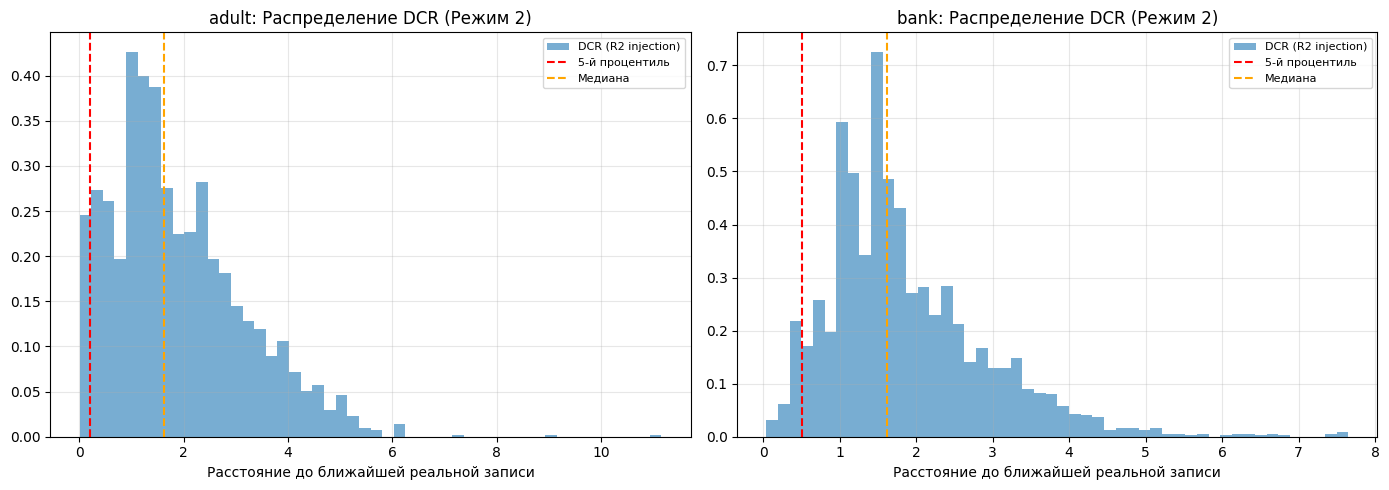

Сохранено в figures/regime2/privacy_dcr_r2.png


In [ ]:
# DCR distribution visualization for R2
fig, axes = plt.subplots(1, len(DATASETS), figsize=(7*len(DATASETS), 5))
if len(DATASETS) == 1: axes = [axes]

for i, name in enumerate(DATASETS.keys()):
    ds_state = DS_STATE[name]
    X_train_real = np.load(f'data/processed/{name}/X_train_alpha_1.00.npy')

    # Sample synthetic points
    X_syn, _ = sample_synthetic_poison(name, int(0.10 * len(X_train_real)), 42, ds_state)
    dcr, nndr = compute_dcr_nndr(X_syn, X_train_real)

    axes[i].hist(dcr, bins=50, alpha=0.6, label='DCR (R2 injection)', density=True, color='tab:blue')
    axes[i].axvline(np.percentile(dcr, 5), color='red', linestyle='--', label='5-й процентиль')
    axes[i].axvline(np.median(dcr), color='orange', linestyle='--', label='Медиана')
    axes[i].set_title(f'{name}: Распределение DCR (Режим 2)')
    axes[i].set_xlabel('Расстояние до ближайшей реальной записи')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/regime2/privacy_dcr_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено в figures/regime2/privacy_dcr_r2.png')

## 12. Final Summary

In [ ]:
print('  REGIME 2 EXPERIMENTS COMPLETE')

import glob
print('\nRegime 2 files saved ')
for f in sorted(glob.glob('results/regime2/*.csv')) + sorted(glob.glob('figures/regime2/*.png')):
    print(f'  {f}')

print('\nSummary: LF Regime Delta ')
lf_d = pd.read_csv('results/regime2/lf_regime_delta.csv')
print(lf_d.to_string(index=False))

print('\nSummary: FP Regime Delta (lambda=1.0) ')
fp_d = pd.read_csv('results/regime2/fp_regime_delta.csv')
print(fp_d.to_string(index=False))

  REGIME 2 EXPERIMENTS COMPLETE

Regime 2 files saved 
  results/regime2/bd_r2_all.csv
  results/regime2/fp_r2_all.csv
  results/regime2/fp_regime_delta.csv
  results/regime2/lf_r2_all.csv
  results/regime2/lf_regime_delta.csv
  results/regime2/privacy_r2.csv
  results/regime2/summary_fp_r2.csv
  results/regime2/summary_lf_r2.csv
  figures/regime2/adult_FP_delta_heatmap.png
  figures/regime2/adult_LF_delta_heatmap.png
  figures/regime2/adult_bd_r1_vs_r2.png
  figures/regime2/adult_fp_lam0.5_r1_vs_r2.png
  figures/regime2/adult_fp_lam1.0_r1_vs_r2.png
  figures/regime2/adult_fp_lam2.0_r1_vs_r2.png
  figures/regime2/adult_lf_r1_vs_r2.png
  figures/regime2/bank_FP_delta_heatmap.png
  figures/regime2/bank_LF_delta_heatmap.png
  figures/regime2/bank_bd_r1_vs_r2.png
  figures/regime2/bank_fp_lam0.5_r1_vs_r2.png
  figures/regime2/bank_fp_lam1.0_r1_vs_r2.png
  figures/regime2/bank_fp_lam2.0_r1_vs_r2.png
  figures/regime2/bank_lf_r1_vs_r2.png
  figures/regime2/privacy_dcr_r2.png

Summary: LF Reg

In [ ]:
# Для R1:
bd_r1 = pd.read_csv('results/backdoor_all.csv')
print(bd_r1.groupby(['dataset','model','alpha','rho'])[['test_auc','asr']].mean().round(4).to_string())

# Для R2:
bd_r2 = pd.read_csv('results/regime2/bd_r2_all.csv')
print(bd_r2.groupby(['dataset','model','alpha','rho'])[['test_auc','asr']].mean().round(4).to_string())

                             test_auc     asr
dataset model   alpha rho                    
adult   LogReg  0.0   0.000    0.8420  0.3608
                      0.005    0.8447  0.5262
                      0.010    0.8457  0.6136
                      0.020    0.8457  0.7530
                      0.050    0.8419  0.9177
                      0.100    0.8351  0.9792
                0.5   0.000    0.8528  0.4139
                      0.005    0.8535  0.5664
                      0.010    0.8534  0.6492
                      0.020    0.8523  0.7634
                      0.050    0.8474  0.9208
                      0.100    0.8408  0.9782
                1.0   0.000    0.8548  0.4185
                      0.005    0.8551  0.5553
                      0.010    0.8547  0.6455
                      0.020    0.8532  0.7577
                      0.050    0.8487  0.9095
                      0.100    0.8424  0.9765
        MLP     0.0   0.000    0.8808  0.1342
                      0.005    0.8